#### Liora Capstone Project
## __Identifying New Factors to Refine Forecasts in Production Quantities in the Food Sector__
+ __course:__ #sep25_continuous_ds
+ __project:__ #sep25cds_int_food_prediction

#### __Context__
The Cologne-based company Foodforecast develops AI-based software that analyzes sales data and generates precise demand forecasts for bakeries, restaurants, and food retailers. This helps automate planning, increase revenue, and significantly reduce food waste by producing or ordering the right quantities.

#### __Objectives__
1) __The overall objective__ is to predict the sold_quantity of items for the next day and quantify the impact of existing features. Then enrich existing with publicly available data to optimize the predictions. This is a __regression__ issue.
2) __For this notebook:__ Understanding, cleaning the four data sources to have one single dataframe ready for pre-processing and modeling.

# __Phase 1: Data Exploration and Preparation__

In [2]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter, FuncFormatter

In [3]:
# see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)  


#### __Data sources__
From foodforecast we have four data scources as .parquet files:
1) __Sales__: Containig sales data from Qtr 2 2025
2) __Stores__: Containing Store Metadata (Id, zipcode, weekly revenue mean Qtr 1 2025)
3) __Holidays__: Containing a list of holidays dates in and in the corresponding region
3) __weather__: Containnig weather data form the corresponding regions and time span.   

# __Data exploration and data cleaning__

## __Data: Sales__ 


In [4]:
# loading data

# new file, item_id correct
sales = pd.read_parquet('20260317_121949_sales_data.parquet', engine="fastparquet")

# old
#sales = pd.read_parquet('20260218_144523_sales_data.parquet', engine='pyarrow')
# alternative
#sales = pd.read_parquet('20260218_144523_sales_data.parquet', engine="fastparquet")

display(sales.head())

,date,category_name,item_id,sold_quantity,price,revenue,store_id
0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0
1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0
2,2025-04-01,Angebot Heißgetränke,346,25.0,0.0,0.0,0
3,2025-04-01,Angebot Heißgetränke,445,5.0,1.4,7.0,0
4,2025-04-01,Angebot Snack,330,5.0,0.0,0.0,0


### Data Structure



This table contains bakery sales data per day from one client with several stores of the federal district of germany (NRW; northrhine westphalia) in the 2nd quarter of 2025 (1. Apr-30. Jun).

__Variables:__

> __date:__ the day of sales [datetime64[ns]]

> __category_name:__ name of the item category in german [str]

> __item_id__: the unique item id [int64]

> __sold_quantity__: the sales amount of the item per day ---> (this is the __target__ variable) [float64]

> __price__: the item's price [float64]

> __revenue__: the revenue for this date, store, item. [float64]

> __store_id__: unique id of one store [int64]


### Overview

In [5]:

# shape
print('Shape sales:', sales.shape, end='\n\n')

# info
print(sales.info())

# decription numeric and categorical
display(sales.describe())
display(sales.describe(include='object'))


Shape sales: (819964, 7)

<class 'pandas.DataFrame'>
RangeIndex: 819964 entries, 0 to 819963
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           819964 non-null  datetime64[ns]
 1   category_name  819964 non-null  object        
 2   item_id        819964 non-null  int64         
 3   sold_quantity  819964 non-null  float64       
 4   price          802973 non-null  float64       
 5   revenue        802973 non-null  float64       
 6   store_id       819964 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 43.8+ MB
None


,date,item_id,sold_quantity,price,revenue,store_id
count,819964,819964.000000,819964.000000,802973.000000,802973.000000,819964.000000
mean,2025-05-15 16:05:00.762472704,476.338161,15.786687,2.759721,21.888225,28.412778
min,2025-04-01 00:00:00,0.000000,-1.000000,-22.000000,-35.600000,0.000000
25%,2025-04-24 00:00:00,232.000000,1.000000,1.100000,2.750000,11.000000
50%,2025-05-16 00:00:00,458.000000,4.000000,2.700000,10.450000,26.000000
75%,2025-06-07 00:00:00,725.000000,12.000000,3.800000,26.100000,44.000000
max,2025-06-30 00:00:00,953.000000,2425.000000,115.000000,3522.659000,83.000000
std,NaN,281.941474,60.279529,2.074748,38.314472,19.175399


,category_name
count,819964
unique,23
top,Brötchen
freq,225428


In [6]:
# Analyse the distribution of the only categorical variable
print(sales['category_name'].value_counts(normalize=True))
print('\nThe first three categories account for over half of the range.')

category_name
Brötchen                0.274924
Brot                    0.219551
Snack                   0.123447
Kaltgetränke 19%        0.074714
Kuchen                  0.074436
Heißgetränke            0.058925
Feinbäckerei            0.056752
Konditorei              0.042027
Snack Belag             0.027238
Angebot Brötchen        0.014060
Angebot Feinbäckerei    0.007536
Kaltgetränke 7%         0.007128
Printen/Kekse           0.006193
Angebot Heißgetränke    0.005638
Eigerichte              0.003953
Angebot Brot            0.001188
Gastro Gerichte         0.001133
Angebot Snack           0.000817
Frühstücke              0.000138
Printen Waage           0.000120
Angebot Kuchen          0.000079
Brotwaage               0.000001
Angebot Gastro          0.000001
Name: proportion, dtype: float64

The first three categories account for over half of the range.


#### Further Observations
- the max. sold_quantity is very high
- negative quantities

- the max. price is very high
- missing values in price (~2%)
- negative prices

- there is only one line each for Brotwaage and Angebot Gastro

### Data Cleaning

In [7]:
#checks

# any duplicated rows?
print('Duplicates in sales:', sales.duplicated().sum()) 

# any missing values?
missing = sales.isna().sum()
print('\nMissing values:')
print(missing)



Duplicates in sales: 0

Missing values:
date                 0
category_name        0
item_id              0
sold_quantity        0
price            16991
revenue          16991
store_id             0
dtype: int64


,date,category_name,item_id,sold_quantity,price,revenue,store_id
14,2025-04-01,Brot,82,0.0,NaN,NaN,0
34,2025-04-01,Brot,395,0.0,NaN,NaN,0
44,2025-04-01,Brot,542,0.0,NaN,NaN,0
65,2025-04-01,Brot,909,0.0,NaN,NaN,0
74,2025-04-01,Brötchen,50,0.0,NaN,NaN,0
91,2025-04-01,Brötchen,195,0.0,NaN,NaN,0
93,2025-04-01,Brötchen,218,0.0,NaN,NaN,0
94,2025-04-01,Brötchen,231,0.0,NaN,NaN,0
97,2025-04-01,Brötchen,244,0.0,NaN,NaN,0
121,2025-04-01,Brötchen,448,0.0,NaN,NaN,0


###################################################################


,date,item_id,sold_quantity,price,revenue,store_id
count,16991,16991.000000,16991.0,0.0,0.0,16991.000000
mean,2025-05-15 17:12:10.763345152,466.249308,0.0,NaN,NaN,18.980107
min,2025-04-01 00:00:00,15.000000,0.0,NaN,NaN,0.000000
25%,2025-04-24 00:00:00,218.000000,0.0,NaN,NaN,5.000000
50%,2025-05-16 00:00:00,395.000000,0.0,NaN,NaN,10.000000
75%,2025-06-07 00:00:00,840.000000,0.0,NaN,NaN,33.000000
max,2025-06-30 00:00:00,933.000000,0.0,NaN,NaN,59.000000
std,NaN,311.951099,0.0,NaN,NaN,18.429311


###################################################################
Number of missing price:  16991
###################################################################
Looking at the first 10 rows of missing values in price and at the description, we can already assume that our target (sold_quantity) is 0 where price is NaN.


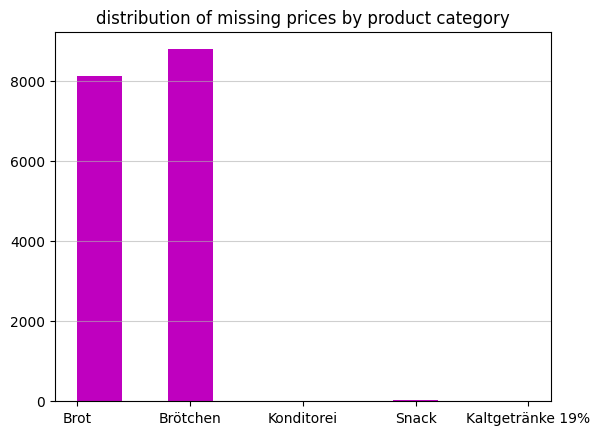

We can also see that the missing values distribute mainly on two categories (Brot and Brötchen).


In [8]:
#Investigate data with missing prices
missing_price = sales[sales['price'].isna()]
display(missing_price.head(10))
print('###################################################################')
display(missing_price.describe())
print('###################################################################')
print('Number of missing price: ', len(missing_price))
print('###################################################################')
#print(missing_price['store_id'].value_counts())
print('Looking at the first 10 rows of missing values in price and at the description, we can already assume that our target (sold_quantity) is 0 where price is NaN.')

plt.hist(missing_price['category_name'], color='m')
plt.title('distribution of missing prices by product category')
plt.grid(axis='y', alpha=0.6)
plt.show()
print('We can also see that the missing values distribute mainly on two categories (Brot and Brötchen).')


In [9]:
# price has also 0 and negative values - why? promotion? discount?
price_gt_0 = sales[sales.price > 0].shape[0]
price_eq_0 = sales[sales.price == 0].shape[0]
price_lt_0 = sales[sales.price <= 0].shape[0]

# all rows 
all_price = sales.price.count()

# percent less than or equal to 0
perc_eq_0 = price_eq_0 / all_price * 100
perc_lt_0 = price_lt_0 / all_price * 100

# calculate proportion of price =< 0
print('Price > 0 \t ->', price_gt_0)
print('Price = 0 \t ->', price_eq_0, f'({perc_eq_0:.1f} %)')
print('Price < 0 \t ->', price_lt_0, f'({perc_lt_0:.1f} %)')
print(f'\n{perc_eq_0:.1f} % of price column are 0 or below ({price_lt_0} ({perc_lt_0:.1f} %) rows below 0)')


##!! Marcel: price == NaN -> sold_quantity always 0 --> can we delete price NaN rows, since you cannnot sell anything w/out a price

## Shuting: The sold quantity in the data with missing prices is always '0' -> remove NAs

# removing row with missing values in price
sales = sales.dropna(subset=['price'])
#display(sales.isna().sum())

# no more missing values
print('\nRemoved missing values in sales:')
display(sales.isna().sum())

Price > 0 	 -> 751794
Price = 0 	 -> 48420 (6.0 %)
Price < 0 	 -> 51179 (6.4 %)

6.0 % of price column are 0 or below (51179 (6.4 %) rows below 0)

Removed missing values in sales:


date             0
category_name    0
item_id          0
sold_quantity    0
price            0
revenue          0
store_id         0
dtype: int64

### __Inverstigating__

__Target variable: sold_quantity__

 - TARGET description - 
count    802973.000000
mean         16.120735
std          60.869734
min          -1.000000
25%           1.000000
50%           4.000000
75%          12.000000
max        2425.000000
Name: sold_quantity, dtype: float64

Whiskers factor: 1.5

Values high threshold: 28.5
Values low threshold: -15.5


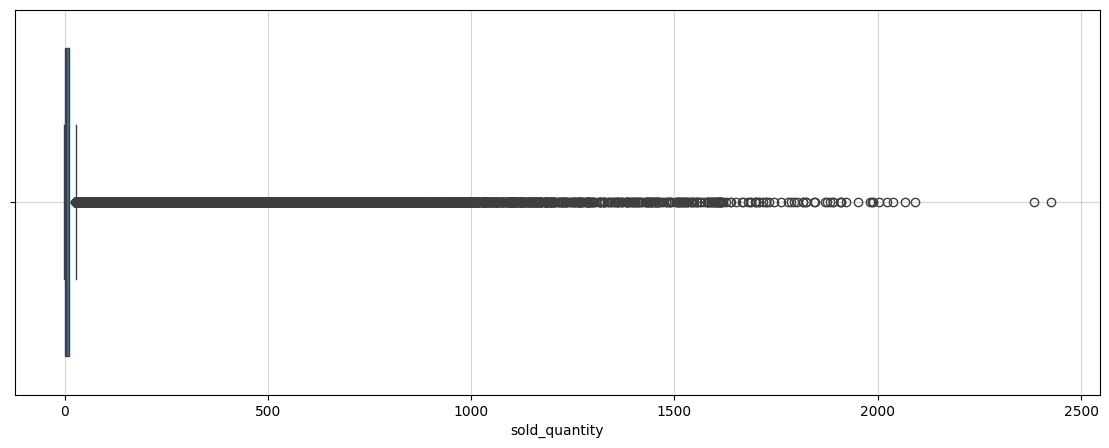

We have 80629 (10.04 %) outliers obove the calculated extreme high threshold.
We have 0 (0.00 %) outliers below the calculated extreme low threshold.

Conclusion: Outliers seem to be too much to  be insignificant. We also do not know anything about the unit.       
There might be a mix, like pieces for bread rolls and weight for bread leafs. Which could explain higher values.      
So we keep the outliers.


In [10]:
# investigating target
print(' - TARGET description - ')
print(sales.sold_quantity.describe())

# -------- Outliers ----------

# boxplot and IQR

# IQR

# calculating quantiles
q1, q2, q3 = sales.sold_quantity.quantile([0.25, 0.5, 0.75])

# inter quartile range
IQR = q3 - q1

whiskers = 1.5

# outliers border
extreme_high = q3 + IQR * whiskers
extreme_low = q1 - IQR * whiskers

print('\nWhiskers factor:', whiskers)
print('\nValues high threshold:', extreme_high)
print('Values low threshold:', extreme_low)

# boxplot
plt.figure(figsize=(14,5))
sns.boxplot(x=sales.sold_quantity, whis=whiskers)
plt.grid(True, 'both', alpha=0.5)
plt.show()

# counting outliers
highs = sales[sales.sold_quantity > extreme_high].shape[0]
lows = sales[sales.sold_quantity < extreme_low].shape[0]

# percentage of outliers
#perc_outliers = outliers_count / len(sales.sold_quantity) * 100
perc_outliers_h = highs / len(sales.sold_quantity) * 100
perc_outliers_l = lows / len(sales.sold_quantity) * 100

print(f'We have {highs} ({perc_outliers_h:.2f} %) outliers obove the calculated extreme high threshold.')
print(f'We have {lows} ({perc_outliers_l:.2f} %) outliers below the calculated extreme low threshold.')

# conclusion
print('\nConclusion: Outliers seem to be too much to  be insignificant. We also do not know anything about the unit. \
      \nThere might be a mix, like pieces for bread rolls and weight for bread leafs. Which could explain higher values.\
      \nSo we keep the outliers.')

In [11]:
# ----- questions and inconsistncies of TARGET-------

# target values < 0 
sold_qty_gt_0 = sales[sales.sold_quantity > 0].shape[0]
sold_qty_eq_0 = sales[sales.sold_quantity == 0].shape[0]
sold_qty_lt_0 = sales[sales.sold_quantity < 0].shape[0]

# all rows 
all_sold = sales.sold_quantity.count()

# percent less than or equal to 0
perc_lt_0 = sold_qty_lt_0 / all_sold * 100
perc_eq_0 = sold_qty_eq_0 / all_sold * 100
 
print('-'*60)
print('\n- TARGET inconsistncies-')
print('sold_quantity > 0 \t ->', sold_qty_gt_0)
print('sold_quantity = 0 \t ->', sold_qty_eq_0, f'({perc_eq_0:.1f} %)')
print('sold_quantity < 0 \t ->', sold_qty_lt_0, f'({perc_lt_0:.1f} %)')

print(f'\n{perc_eq_0:.1f} % of target column are 0 or below ({sold_qty_lt_0} rows only are below 0 and can be neglected).')
print('How to deal with sold_quantity = 0?  What does it say? Is it simply nothing sold or is there a inconsistency in the provided data?')


------------------------------------------------------------

- TARGET inconsistncies-
sold_quantity > 0 	 -> 697728
sold_quantity = 0 	 -> 105243 (13.1 %)
sold_quantity < 0 	 -> 2 (0.0 %)

13.1 % of target column are 0 or below (2 rows only are below 0 and can be neglected).
How to deal with sold_quantity = 0?  What does it say? Is it simply nothing sold or is there a inconsistency in the provided data?


__Variable: price__

 - price description - 
count    802973.000000
mean          2.759721
std           2.074748
min         -22.000000
25%           1.100000
50%           2.700000
75%           3.800000
max         115.000000
Name: price, dtype: float64

Whiskers factor: 1.5

Values high threshold: 7.85
Values low threshold: -2.9499999999999997


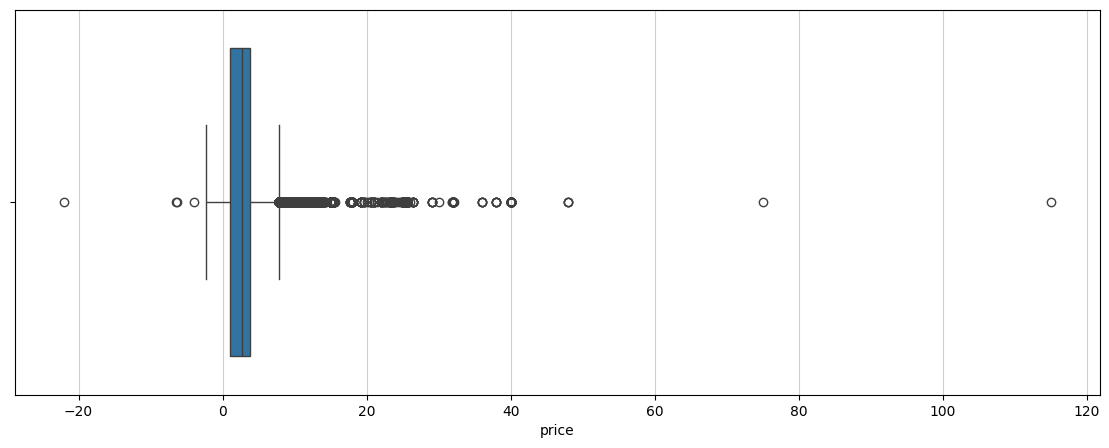

We have 24194 (3.01 %) outliers obove the calculated extreme high threshold.
We have 4 (0.00 %) outliers below the calculated extreme low threshold.

Sample example: data with prices > 60€


,date,category_name,item_id,sold_quantity,price,revenue,store_id
224576,2025-04-26,Konditorei,464,1.0,115.0,115.0,5
283694,2025-05-03,Konditorei,452,1.0,75.0,75.0,5



Conclusion: The higher prices are for Konditorei can be comprehensible and realistic. They look like reasonable prices for, e.g. birthday cakes which can be ordered and are much higher in price than bread rolls.
However, it should be analysed later whether the outliers will affect the performance of the model


In [12]:
# investigating price

print(' - price description - ')
print(sales.price.describe())

# -------- Outliers price----------

# boxplot and IQR

# IQR

# calculating quantiles
q1, q2, q3 = sales.price.quantile([0.25, 0.5, 0.75])

# inter quartile range
IQR = q3 - q1

whiskers = 1.5

# outliers border
extreme_high = q3 + IQR * whiskers
extreme_low = q1 - IQR * whiskers

print('\nWhiskers factor:', whiskers)
print('\nValues high threshold:', extreme_high)
print('Values low threshold:', extreme_low)

#check the distribution of prices
plt.figure(figsize=(14,5))
sns.boxplot(x=sales['price'])
plt.grid(axis='x', alpha=0.6)
plt.show()


# counting outliers
highs = sales[sales.price > extreme_high].shape[0]
lows = sales[sales.price < extreme_low].shape[0]

# percentage of outliers
#perc_outliers = outliers_count / len(sales.price) * 100
perc_outliers_h = highs / len(sales.price) * 100
perc_outliers_l = lows / len(sales.price) * 100

print(f'We have {highs} ({perc_outliers_h:.2f} %) outliers obove the calculated extreme high threshold.')
print(f'We have {lows} ({perc_outliers_l:.2f} %) outliers below the calculated extreme low threshold.')

# example price
print('\nSample example: data with prices > 60€')
display(sales[sales['price'] > 60 ])
print()

# conclusion
print('Conclusion: The higher prices are for Konditorei can be comprehensible and realistic. They look like reasonable prices for, e.g. birthday cakes which can be ordered and are much higher in price than bread rolls.')
print('However, it should be analysed later whether the outliers will affect the performance of the model')




In [13]:
# strange in price

# there a items sold "for free" or without a price (price == 0) but sold qty > 0.

# filter condition
strange_solds_cond = (sales.sold_quantity != 0) & (sales.price == 0)

# filter records
strange_solds = sales[strange_solds_cond] # -> more than 40,000 rows have sold items but no price. since our target it quantity sold, i would leave this untouched
print('Sample of items sold with sold_quantity > 0 but a price = 0:\n')

# display a sample of data
display(strange_solds.sample(8))

strange_solds_count = strange_solds.shape[0]

perc_strange_solds = strange_solds_count / len(sales.sold_quantity) * 100

print(f'Count of items sold with price = 0: {strange_solds_count} ({perc_strange_solds:.2f} %).' )
print('\nHow do we deal with those occurences in price and sold_quantity?\n')
print('Assumption: These are results of promotion (buy one, get two, etc.) or give-a-ways (give away for free short before closing time) , so it \nseems reasonable that there are items giving away for free, i.e. without price.')

Sample of items sold with sold_quantity > 0 but a price = 0:



,date,category_name,item_id,sold_quantity,price,revenue,store_id
805452,2025-06-28,Brötchen,939,1.0,0.0,0.0,80
450976,2025-05-20,Angebot Snack,808,1.0,0.0,0.0,33
428485,2025-05-17,Angebot Feinbäckerei,203,1.0,0.0,0.0,56
477895,2025-05-23,Angebot Feinbäckerei,203,1.0,0.0,0.0,8
304083,2025-05-05,Angebot Heißgetränke,346,3.0,0.0,0.0,32
497258,2025-05-24,Brot,538,3.0,0.0,0.0,67
397714,2025-05-14,Brötchen,386,19.0,0.0,0.0,76
393823,2025-05-14,Angebot Brötchen,547,1.0,0.0,0.0,34


Count of items sold with price = 0: 41826 (5.21 %).

How do we deal with those occurences in price and sold_quantity?

Assumption: These are results of promotion (buy one, get two, etc.) or give-a-ways (give away for free short before closing time) , so it 
seems reasonable that there are items giving away for free, i.e. without price.


__Variable: item_id__

In [14]:
# investigating item_id

# strange
# some item_id (expected to be unique) appear in 2 category_names

#### before correction
# print('Item_ids belonging to more than 1 category:\n')
# for item in sales['item_id'].unique():
#     category = sales[(sales['item_id'] == item) & (sales['sold_quantity'] > 0)]['category_name'].unique()
#     if len(category) > 1:
#         print(f'{item} \t {list(category)}')
    

# after correction (just to make sure that item_id are clean now)
item_id_check = sales.groupby('item_id')['category_name'].apply(set)
cat_count = item_id_check.apply(lambda x: len(x))

print('Unique item_ids: ', sales.item_id.nunique())
print('Item_ids belonging to only 1 category_name:', item_id_check[cat_count == 1].shape[0])
print('Item_ids belonging more than 1 category_name:', item_id_check[cat_count > 1].shape[0])

Unique item_ids:  922
Item_ids belonging to only 1 category_name: 922
Item_ids belonging more than 1 category_name: 0


In [15]:
## no longer neccessary

# distribution of category_name per item per store
# sales_item_id = pd.DataFrame(sales.groupby(['store_id', 'item_id'])['category_name']\
#                              .apply(lambda x: pd.Series(x)\
#                              .value_counts(normalize=True)))

# count every occurences of category_names
# counts = sales_item_id.groupby(['store_id', 'item_id'])['category_name'].transform('size')

# # filter non-unique item_id appearing in more than one category_name
# item_id_dups = sales_item_id[counts > 1].rename(columns={'category_name': 'distribution_category_name'})

# print('Distribution of category_name appearing more then once per item_id per store:\n')
# display(item_id_dups.head(30))
# print('Sometimes the distribution of the category_name is very uneven (e.g. item_id = 58), while in other places it is fairly dense (e.g. item_id = 59).')

# print('One item_id might refer to different products with differnt prices, even within the same store')

In [16]:
## not longer neccessary

# Sample example item_id == 59
# -> same item_id -> different category_names -> different prices -> different stores

# print('Example item_id 59: Different category and price for same item_id in same store:\n')
# display(sales[(sales['item_id'] == 59)].head(15))

# print('To do: clarify item id with data provider')


### Prepare for visualization and merging

In [17]:
# Remove the negative quantities and one time occurences "Angebot Gastro" & "Brotwaage"
sales_adj = sales[(sales['category_name'] != 'Brotwaage') & (sales['category_name'] != 'Angebot Gastro')]
sales_adj = sales_adj[sales_adj['sold_quantity'] >= 0]

In [18]:
# enrich dates for better analysis and visuaiisation
sales_adj['month'] = sales_adj.date.dt.month
sales_adj['day_of_week'] = sales_adj.date.dt.day_of_week
sales_adj['week'] = sales_adj.date.dt.isocalendar().week
sales_adj.head()

,date,category_name,item_id,sold_quantity,price,revenue,store_id,month,day_of_week,week
0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0,4,1,14
1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0,4,1,14
2,2025-04-01,Angebot Heißgetränke,346,25.0,0.0,0.0,0,4,1,14
3,2025-04-01,Angebot Heißgetränke,445,5.0,1.4,7.0,0,4,1,14
4,2025-04-01,Angebot Snack,330,5.0,0.0,0.0,0,4,1,14


## __Data: Stores__ 


In [19]:
# loading stores

# new file
stores = pd.read_parquet('20260317_121949_stores.parquet', engine='fastparquet')

# old file
#stores = pd.read_parquet('20260218_144523_stores.parquet', engine='pyarrow')
#stores = pd.read_parquet('20260218_144523_stores.parquet', engine='fastparquet')

stores.head()


,subdivision_code,country_code,zipcode,average_weekly_revenue_Q1,store_id
0,DE-NW,DE,52062,31320.584186,0
1,DE-NW,DE,52224,26099.178461,1
2,DE-NW,DE,52134,23670.235995,2
3,DE-NW,DE,52062,26933.337776,3
4,DE-NW,DE,52222,21000.922881,4


### Data Structure

This table contains store meta data of __serveral stores__ belonging to __one client__. 

__Variables:__

> __subdivision_code:__ The abbreviation for the federal state in Germany [str, categorical]

> __country_code__: The code of the country [str, categorical]

> __zipcode__: The postal code of the area where the store is located [int64, categorical]

> __average_weekly_revenue_Q1__: The average weekly revenue per store from Qtr 1 2025 (we have sales data form Qtr2) [float64, quantitative]

> __store_id__: The unique Id of a store [float64, categorical]

> 


### Overview

In [20]:
# overview

# shape
print('Shape stores:', stores.shape, end='\n\n')

# info
print(stores.info())

# decription numeric and categorical
display(stores.describe())
display(stores.describe(include='object'))

Shape stores: (84, 5)

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subdivision_code           84 non-null     object 
 1   country_code               84 non-null     object 
 2   zipcode                    84 non-null     object 
 3   average_weekly_revenue_Q1  84 non-null     float64
 4   store_id                   84 non-null     int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 3.4+ KB
None


,average_weekly_revenue_Q1,store_id
count,84.000000,84.000000
mean,15666.444458,41.500000
std,12225.252515,24.392622
min,0.000000,0.000000
25%,0.000000,20.750000
50%,16085.267846,41.500000
75%,23903.234941,62.250000
max,45425.349452,83.000000


,subdivision_code,country_code,zipcode
count,84,84,84
unique,1,1,36
top,DE-NW,DE,52064
freq,84,84,5


### Data Cleaning

In [21]:
## duplicates?
print('Dublicates in store:', stores.duplicated().sum())

# missing values
print('\nMissing values:')
print(stores.isna().sum())


Dublicates in store: 0

Missing values:
subdivision_code             0
country_code                 0
zipcode                      0
average_weekly_revenue_Q1    0
store_id                     0
dtype: int64


In [22]:
# deleting constant variables

print('Since the variables country_code and subdivision_code contain only ONE constant value, they do not provide any \
\nadditional information and can be deleted.')

stores = stores.drop(columns=['subdivision_code', 'country_code'], errors='ignore')

# check
display(stores.head())


Since the variables country_code and subdivision_code contain only ONE constant value, they do not provide any 
additional information and can be deleted.


,zipcode,average_weekly_revenue_Q1,store_id
0,52062,31320.584186,0
1,52224,26099.178461,1
2,52134,23670.235995,2
3,52062,26933.337776,3
4,52222,21000.922881,4


### __Investigating__

In [23]:
# revenue qtr2 vs. qtr1

# we have the average weekly revenue for Qtr 1. Lets see how that revenue is in Qtr 2.

# creating a new column in sales to calculate the revenue of Qtr 2
sales_adj['revenue'] = sales_adj.price * sales_adj.sold_quantity
#display(sales.sort_values('revenue', ascending=False))

# creating revenue per store and per week for Qtr 2
rev_q2_week = pd.DataFrame(sales_adj.groupby(['store_id', 'week'])['revenue'].sum())
rev_q2_week.sort_values('revenue', ascending=False)

# creating average of weekly revenue Qtr 2
average_weekly_revenue_Q2 = rev_q2_week.groupby('store_id')['revenue'].mean()

# putting result in a dataframe and renaming the column
average_weekly_revenue_Q2 = pd.DataFrame(average_weekly_revenue_Q2).rename(columns={'revenue':'average_weekly_revenue_Q2'})

# concat rev qtr 2 to stores
# merge revenue variable for Qtr 2 and store (with revenue Qtr 1) into new df
stores_rev = pd.merge(left=stores, right=average_weekly_revenue_Q2, on='store_id')

display(stores_rev.sort_values('store_id').tail(30))

print('Looking at the tail we got the assumption that there might be stores in the table that do not have any revenue.')


,zipcode,average_weekly_revenue_Q1,store_id,average_weekly_revenue_Q2
54,52249,16719.604164,54,16025.372450
55,52477,19059.509514,55,17870.876200
56,52222,9326.370893,56,8585.564607
57,52222,13355.194107,57,12745.108945
58,52062,34775.263573,58,31596.955669
59,52074,22350.059336,59,21947.204764
60,52064,0.000000,60,0.000000
61,52068,0.000000,61,0.000000
62,52078,0.000000,62,0.000000
63,52477,0.000000,63,0.000000


Looking at the tail we got the assumption that there might be stores in the table that do not have any revenue.


In [24]:
# melting avg weekly columns for plotting
stores_rev_melt = stores_rev.melt(id_vars='store_id', value_vars=['average_weekly_revenue_Q1', 'average_weekly_revenue_Q2'], var_name='Qtr', value_name='avg_weekly_rev')

# renaming values of Qtr to 1 or 2
stores_rev_melt['Qtr'] = stores_rev_melt.Qtr.str[24:]

# check
stores_rev_melt.head()

,store_id,Qtr,avg_weekly_rev
0,0,1,31320.584186
1,1,1,26099.178461
2,2,1,23670.235995
3,3,1,26933.337776
4,4,1,21000.922881


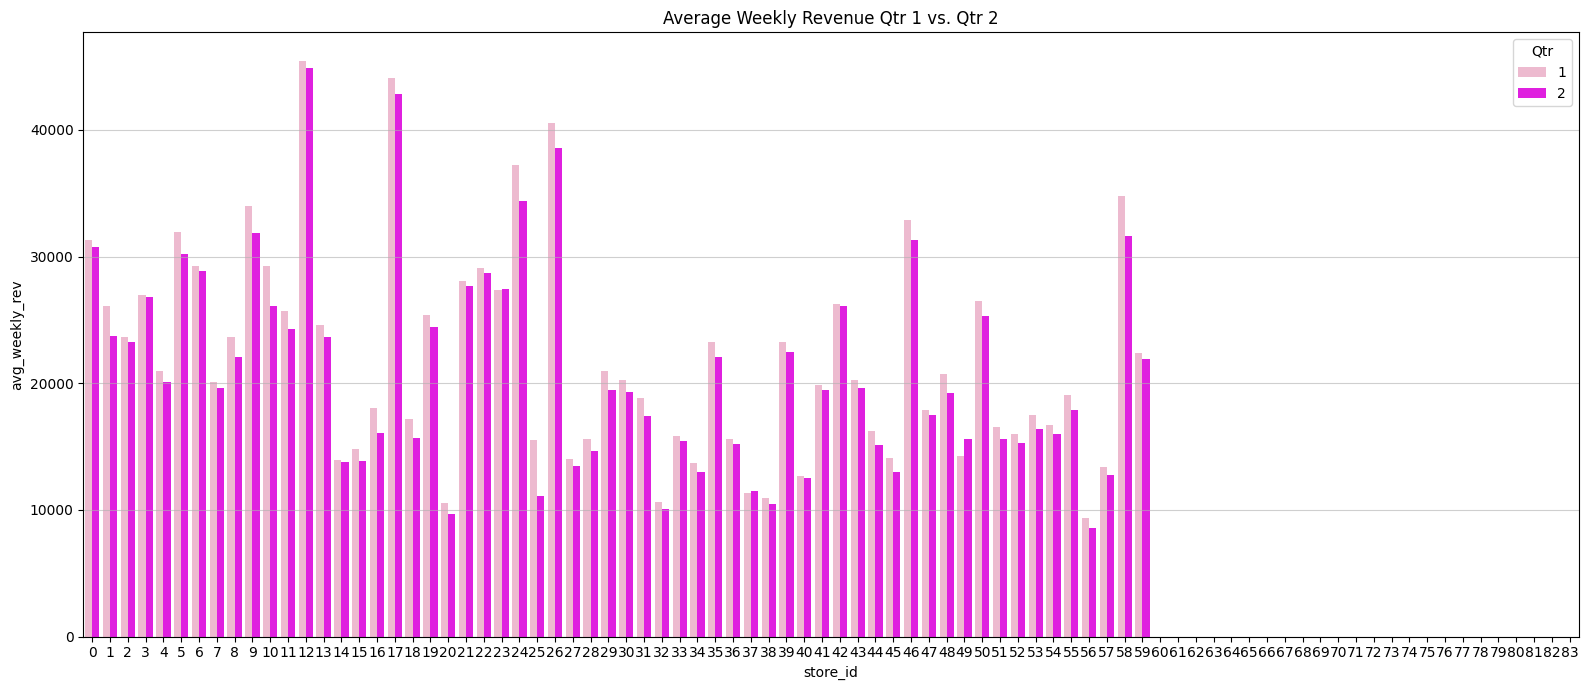

Conclusion: Stores with the Id of >= 60 have no revenue in Qtr 1 and Qtr 2, which means they did not sell anything. 
But sometimes the sold_quantity column is > 0, sometime price is > 0. Strange!


In [25]:
# weekly rev qtr1 2025 by store: plot

# barplot to visualize out assumtion
plt.figure(figsize=(16,7))

bars = sns.barplot(data=stores_rev_melt, x='store_id', y='avg_weekly_rev', hue='Qtr', palette=['#F6B1CE', '#FF00FF'])
plt.grid(axis='y', alpha=0.6)
plt.title('Average Weekly Revenue Qtr 1 vs. Qtr 2')
plt.tight_layout()
plt.show()


# conclusion store_id  >= 60
print('Conclusion: Stores with the Id of >= 60 have no revenue in Qtr 1 and Qtr 2, which means they did not sell anything. \nBut sometimes the sold_quantity column is > 0\
, sometime price is > 0. Strange!')

In [26]:
# indeed we cannot find a combination of the stores listed >= 60 that have a positive price AND a positive sold_quantity

cond = (sales_adj.store_id >= 60) & (sales_adj.price > 0) & (sales_adj.sold_quantity > 0) 
print(f'Count of Store_id >= 60 and price > 0 and sold_quantity > 0:  {sales_adj[cond].shape[0]}')
print('\nThat means EITHER the price is 0 OR the sold_quantity is 0. This does not make sense because these stores constantly sell sth. without a price or items which\
      \nhave a price are not sold once.')
print('Conclusion: We cannot rely on data for stores with the id >= 60. It might be those stores are already listed but not do not privide any data yet. Or maybe\
      \nthere is another consistency we do not know. For further analysis those stores should be removed from the sales and stores dataframes.')

print('\nto do: clarify store_id with data provider. ----> done ✅, got corrected version of item_id')

Count of Store_id >= 60 and price > 0 and sold_quantity > 0:  0

That means EITHER the price is 0 OR the sold_quantity is 0. This does not make sense because these stores constantly sell sth. without a price or items which      
have a price are not sold once.
Conclusion: We cannot rely on data for stores with the id >= 60. It might be those stores are already listed but not do not privide any data yet. Or maybe      
there is another consistency we do not know. For further analysis those stores should be removed from the sales and stores dataframes.

to do: clarify store_id with data provider. ----> done ✅, got corrected version of item_id


### __Prepare for merging__

In [27]:
# we have already deleted constand variables - now we delete average_weekly_revenure_Q1. We don't need it for modeling.
# we only need zipcode and store_id of this data.


# NOTE: since we got in sales data V2 the revenue for Q2 - it may be good to keep the revenure


#stores = stores.drop('average_weekly_revenue_Q1', axis=1, errors='ignore')
#stores_rev.head()

# re-arranging column order to make it cleaner
stores_rev = stores_rev[['store_id', 'zipcode', 'average_weekly_revenue_Q1', 'average_weekly_revenue_Q2']]
stores_rev.head()


,store_id,zipcode,average_weekly_revenue_Q1,average_weekly_revenue_Q2
0,0,52062,31320.584186,30746.697574
1,1,52224,26099.178461,23763.321948
2,2,52134,23670.235995,23217.862510
3,3,52062,26933.337776,26807.825895
4,4,52222,21000.922881,20077.335996


## __Data: Holidays__

In [28]:
# loading data

# new file
holidays = pd.read_parquet('20260317_121949_holidays.parquet ', engine='fastparquet')

# old file
#holidays = pd.read_parquet('20260218_144523_holidays.parquet', engine='pyarrow')
#holidays = pd.read_parquet('20260218_144523_holidays.parquet', engine='fastparquet')
holidays.head()


,zipcode,subdivision_code,date,holiday_name,holiday_type
0,41812,DE-NW,2025-04-01,Zuckerfest,special_day
1,41812,DE-NW,2025-04-02,Zuckerfest,special_day
2,41812,DE-NW,2025-04-12,Osterferien,school_holiday
3,41812,DE-NW,2025-04-13,Osterferien,school_holiday
4,41812,DE-NW,2025-04-13,Palmsonntag,special_day


### Data Structure

This table contains a list of holiday of differnt typ.

__Variables:__

> __zipcode__: The postal code of the area where the holiday takes place. [str, categorical]

> __subdivision_code:__ The abbreviation for the federal state in Germany where the holiday takes place. [str, categorical]

> __date__: The date of the holiday of a holiday span. [datetime[ns], categorical]

> __holiday_name__: The name of the holiday(s) [str, categorical]

> __holiday_type__: The type of the holiday(s) [str, categorical]

### Overview


In [29]:
# shape
print('Shape holidays:', holidays.shape, end='\n\n')

# info
print(holidays.info())

# decription numeric and categorical
display(holidays.describe())
display(holidays.describe(include='object'))

Shape holidays: (1301, 5)

<class 'pandas.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   zipcode           1301 non-null   object        
 1   subdivision_code  1301 non-null   object        
 2   date              1301 non-null   datetime64[ns]
 3   holiday_name      1301 non-null   object        
 4   holiday_type      1301 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 50.9+ KB
None


,date
count,1301
mean,2025-05-01 14:05:37.586471936
min,2025-04-01 00:00:00
25%,2025-04-17 00:00:00
50%,2025-04-22 00:00:00
75%,2025-05-11 00:00:00
max,2025-06-24 00:00:00


,zipcode,subdivision_code,holiday_name,holiday_type
count,1301,1301,1301,1301
unique,36,2,19,3
top,52531,DE-NW,Osterferien,school_holiday
freq,76,1260,598,635


### Data Cleaning

In [30]:
# duplicates?
print('Duplicates:', holidays.duplicated().sum())

# missing values?
print('Missing values:', holidays.isna().sum().sum())

# 
print('\nActually, a 2nd federal subdivision sneaked its way in...  -> ', list(holidays.subdivision_code.unique()))

# record with "wrong" subdivision_code
cond = holidays.subdivision_code == 'DE-BB'

# list with zipcodes in 2nd subdivision
subs = list(holidays[cond].zipcode.unique())

print('\nZipcode for different subdivision:', subs)
print(f'Conclusion: Since the subdivision_code {subs} belongs to "DE-NW", there seems to be a mistake. We would replace it with the correct code.')
print('BUT: Since the variable subdivision_code has only one constant value, it provides no additional information and should be completly removed.')

# remove subdivision_code
holidays = holidays.drop(columns=['subdivision_code'])
holidays.head()

Duplicates: 0
Missing values: 0

Actually, a 2nd federal subdivision sneaked its way in...  ->  ['DE-NW', 'DE-BB']

Zipcode for different subdivision: ['52531']
Conclusion: Since the subdivision_code ['52531'] belongs to "DE-NW", there seems to be a mistake. We would replace it with the correct code.
BUT: Since the variable subdivision_code has only one constant value, it provides no additional information and should be completly removed.


,zipcode,date,holiday_name,holiday_type
0,41812,2025-04-01,Zuckerfest,special_day
1,41812,2025-04-02,Zuckerfest,special_day
2,41812,2025-04-12,Osterferien,school_holiday
3,41812,2025-04-13,Osterferien,school_holiday
4,41812,2025-04-13,Palmsonntag,special_day


### __Investigating__

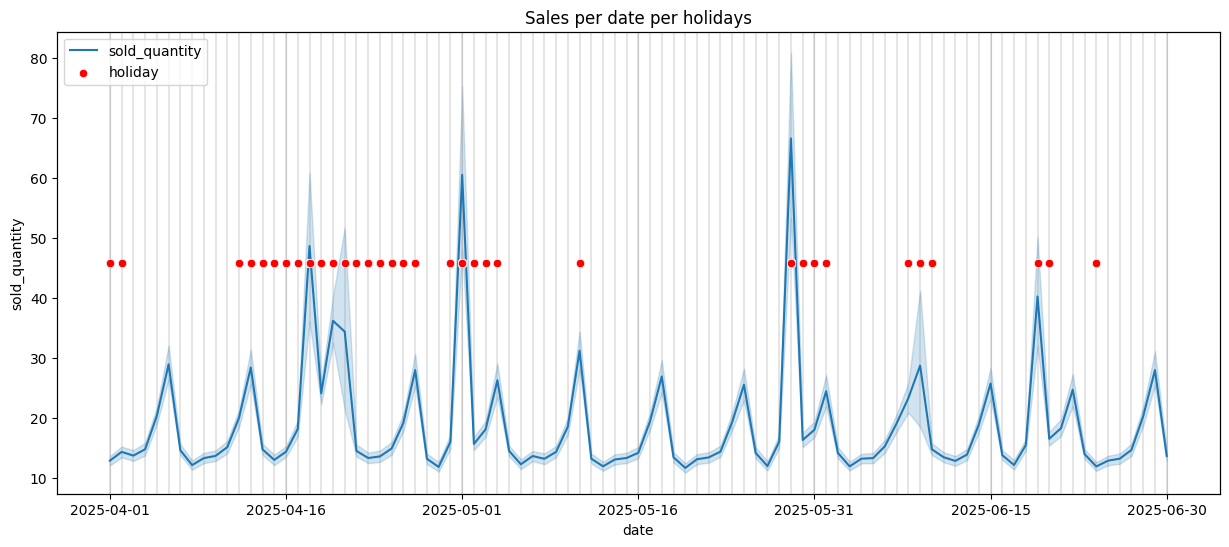

We can see some sales peaks on a few but not all holidays.


In [31]:
# plotting sold_quantity per date and is_holiday

# adding a boolean for holiday
holidays['is_holiday'] = 1

# adding date fragments
holidays['day_of_month'] = holidays.date.dt.day
holidays['week'] = holidays.date.dt.isocalendar().week
holidays

# plot
fig, ax = plt.subplots(1,1, figsize=(15,6))

sns.lineplot(sales, x='date', y='sold_quantity', label='sold_quantity', ax=ax, legend=False)

# 2nd y-axis on the right
ax2 = ax.twinx()
sns.scatterplot(holidays, x='date', y='is_holiday', color='r',label='holiday', ax=ax2, legend=False)

# getting labels of both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper left')

# all dates for grid
all_dates = pd.date_range(start=min(holidays['date'].min(), sales['date'].min()),
                          end=max(holidays['date'].max(), sales['date'].max()),
                          freq='D')

ax.set_xticks(all_dates[::15])  
ax.grid(True, which='both', axis='x', alpha=0.6) 


# additional lines per day
for d in all_dates:
    ax.axvline(d, color='gray', linestyle='-', alpha=0.2, zorder=0)

#ax.grid(True, alpha=0.6)
plt.title('Sales per date per holidays')
plt.xticks(rotation=65)
ax2.set_yticks([])
ax2.set_ylabel('')
plt.show()

print('We can see some sales peaks on a few but not all holidays.')

### Prepare for visualization and merging

In [32]:
print('Type of holidays: ', holidays['holiday_type'].unique())

# separate holidays by type and create unique keys (zipcode + date) for each category
special_days = holidays[holidays['holiday_type'] == 'special_day']
special_days_index = special_days['zipcode'].astype('str') + special_days['date'].astype('str')

school_holidays = holidays[holidays['holiday_type'] == 'school_holiday']
school_holidays_index = school_holidays['zipcode'].astype('str') + school_holidays['date'].astype('str')

std_holidays = holidays[holidays['holiday_type'] == 'holiday']
std_holidays_index = std_holidays['zipcode'].astype('str') + std_holidays['date'].astype('str')

Type of holidays:  ['special_day' 'school_holiday' 'holiday']


## __Data: Weather__

In [33]:
# data loading

# new file
weather = pd.read_parquet('20260317_121949_weather.parquet ', engine= 'fastparquet')


# old file
#weather = pd.read_parquet('20260218_144523_weather.parquet', engine='pyarrow')
#weather = pd.read_parquet('20260218_144523_weather.parquet', engine= 'fastparquet')
display(weather.head())

,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_code,weather_description,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,chanceofrain,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
0,2025-04-01,20:00,41812,10.0,16.0,79.0,ENE,113,Clear,0.0,56.0,10.0,1024.0,0.0,10.0,1.0,7.0,32.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2025-04-01,21:00,41812,9.0,16.0,75.0,ENE,113,Clear,0.0,60.0,10.0,1024.0,1.0,9.0,1.0,6.0,32.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2025-04-01,22:00,41812,9.0,18.0,71.0,ENE,113,Clear,0.0,62.0,10.0,1025.0,0.0,9.0,2.0,6.0,33.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2025-04-01,23:00,41812,8.0,20.0,70.0,ENE,113,Clear,0.0,63.0,10.0,1025.0,2.0,8.0,2.0,5.0,35.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2025-04-01,00:00,41812,6.0,10.0,52.0,NE,113,Clear,0.0,74.0,10.0,1028.0,0.0,6.0,2.0,4.0,21.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Overview

In [34]:
# shape
print('Shape holidays:', weather.shape, end='\n\n')

# info
print(weather.info())

# decription numeric and categorical
display(weather.describe())
display(weather.describe(include='object'))

Shape holidays: (78624, 30)

<class 'pandas.DataFrame'>
RangeIndex: 78624 entries, 0 to 78623
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 78624 non-null  datetime64[ns]
 1   time                 78624 non-null  object        
 2   zipcode              78624 non-null  object        
 3   temperature          78624 non-null  float64       
 4   wind_speed           78624 non-null  float64       
 5   wind_degree          78624 non-null  float64       
 6   wind_dir             78624 non-null  object        
 7   weather_code         78624 non-null  int64         
 8   weather_description  78624 non-null  object        
 9   precip               78624 non-null  float64       
 10  humidity             78624 non-null  float64       
 11  visibility           78624 non-null  float64       
 12  pressure             78624 non-null  float64       
 13  cloudcover   

,date,temperature,wind_speed,wind_degree,weather_code,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,chanceofrain,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
count,78624,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.000000
mean,2025-05-16 00:00:00,13.819521,13.142577,177.389474,141.274267,0.059655,69.556853,9.577101,1018.022563,39.178139,13.974295,7.872265,12.926804,20.037635,12.998766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.633916
min,2025-04-01 00:00:00,-2.000000,0.000000,0.000000,113.000000,0.000000,23.000000,0.000000,998.000000,0.000000,-2.000000,-11.000000,-6.000000,0.000000,-6.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
25%,2025-04-23 00:00:00,10.000000,9.000000,87.000000,113.000000,0.000000,57.000000,10.000000,1015.000000,7.000000,10.000000,5.000000,8.000000,14.000000,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
50%,2025-05-16 00:00:00,13.000000,12.000000,204.000000,116.000000,0.000000,71.000000,10.000000,1018.000000,26.000000,13.000000,8.000000,12.000000,19.000000,12.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
75%,2025-06-08 00:00:00,17.000000,17.000000,257.000000,143.000000,0.000000,84.000000,10.000000,1022.000000,74.000000,17.000000,11.000000,17.000000,25.000000,17.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.000000
max,2025-06-30 00:00:00,32.000000,39.000000,360.000000,389.000000,8.500000,99.000000,10.000000,1029.000000,100.000000,33.000000,22.000000,32.000000,61.000000,33.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.000000
std,NaN,5.665801,6.522310,101.179081,57.894296,0.288629,16.739121,1.750297,5.612091,35.601236,5.907601,4.512992,6.374721,8.706802,6.507605,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.890117


,time,zipcode,wind_dir,weather_description
count,78624,78624,78624,78624
unique,24,36,16,25
top,20:00,41812,WSW,Clear
freq,3276,2184,9285,20955


### Data Structure

This table contains weather indicators observed in the given time span of Qtr 2, 2025

> **date**: The calendar date on which the weather observation was recorded. [datetime64, categorical]

> **time**: The time of day when the weather measurement was taken. [str, categorical]

> **zipcode**: The postal code representing the geographic area where the weather observation was recorded. [str, categorical]

> **temperature**: The measured air temperature at the given location and time, typically expressed in degrees Celsius. [float, quantitative]

> **wind_speed**: The speed of the wind at the time of observation. [float, quantitative]

> **wind_degree**: The wind direction expressed in degrees, indicating the direction from which the wind originates. [float, quantitative]

> **wind_dir**: The cardinal direction of the wind (e.g., N, NE, SW) describing where the wind is coming from. [str, categorical]

> **weather_code**: A numeric code representing the general weather condition according to a predefined weather classification scheme. [int, categorical]

> **weather_description**: A textual description of the observed weather conditions (e.g., cloudy, light rain). [str, categorical]

> **precip**: The amount of precipitation recorded during the observation period. [float, quantitative]

> **humidity**: The relative humidity in the air expressed as a percentage. [float, quantitative]

> **visibility**: The distance at which objects can be clearly seen in the atmosphere. [float, quantitative]

> **pressure**: The atmospheric pressure measured at the observation location. [float, quantitative]

> **cloudcover**: The proportion of the sky covered by clouds expressed as a percentage. [float, quantitative]

> **heatindex**: The perceived temperature combining air temperature and humidity to represent how hot it feels to humans. [float, quantitative]

> **dewpoint**: The temperature at which air becomes saturated and water vapor begins to condense into dew. [float, quantitative]

> **windchill**: The perceived decrease in air temperature felt by the body due to wind. [float, quantitative]

> **windgust**: The maximum short burst of wind speed recorded during the observation period. [float, quantitative]

> **feelslike**: The perceived outdoor temperature considering factors such as humidity and wind. [float, quantitative]

> **chanceofrain**: The probability that rain will occur during the forecast period, expressed as a percentage. [float, quantitative]

> __chanceofremdry__: The probability that no precipitation will occur during the forecast period. [float, quantitative]

> **chanceofwindy**: The probability that windy conditions will occur during the forecast period. [float, quantitative]

> **chanceofovercast**: The probability that the sky will be mostly or completely covered by clouds. [float, quantitative]

> **chanceofsunshine**: The probability that sunny conditions will occur during the forecast period. [float, quantitative]

> **chanceoffrost**: The probability that frost conditions may occur. [float, quantitative]

> **chanceofhightemp**: The probability that temperatures will reach unusually high levels. [float, quantitative]

> **chanceoffog**: The probability that foggy conditions will occur. [float, quantitative]

> **chanceofsnow**: The probability that snowfall will occur. [float, quantitative]

> **chanceofthunder**: The probability that thunderstorm activity will occur. [float, quantitative]

> **uv_index**: The ultraviolet radiation index indicating the strength of sunburn-causing UV radiation. [float, quantitative]

### Data Cleaning

In [35]:
# duplicates?
print('Duplicates:', weather.duplicated().sum())

# missing values?
print('Missing values:', weather.isna().sum().sum())


Duplicates: 0
Missing values: 0


### __Investigating__ 

chanceofrain  chanceofremdry  chanceofwindy  chanceofovercast  chanceofsunshine  chanceoffrost  chanceofhightemp  chanceoffog  chanceofsnow  chanceofthunder
0.0           0.0             0.0            0.0               0.0               0.0            0.0               0.0          0.0           0.0                78624
Name: count, dtype: int64

Only the value 0 is in all chancesof cols.


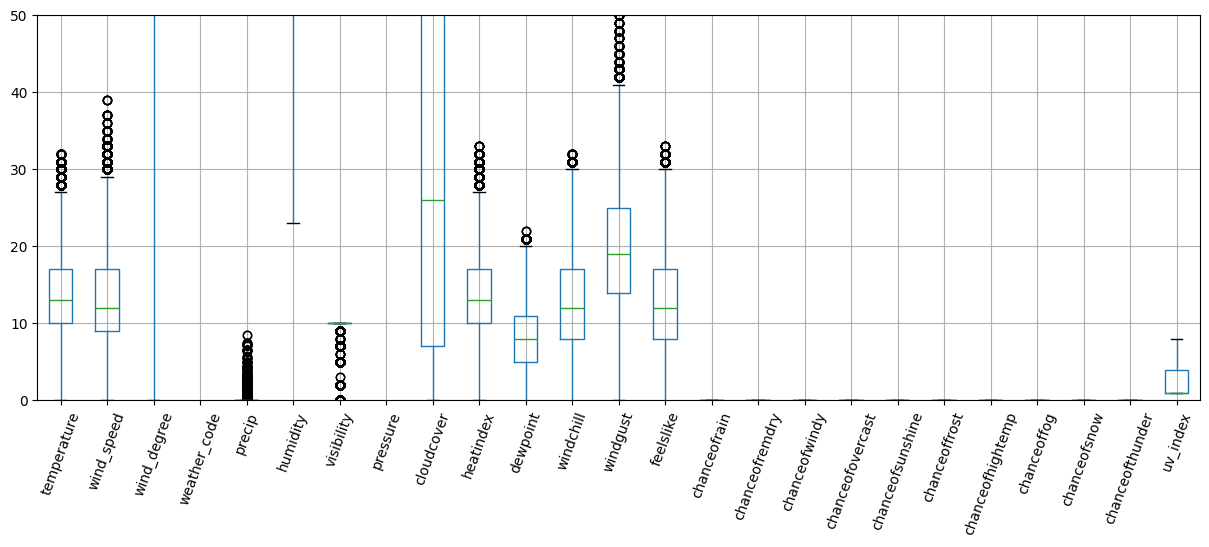

Conclusion: Those columns only have one constant value (0), i.e. they do not provide information for a model -> we delete them.


,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_code,weather_description,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,uv_index
0,2025-04-01,20:00,41812,10.0,16.0,79.0,ENE,113,Clear,0.0,56.0,10.0,1024.0,0.0,10.0,1.0,7.0,32.0,7.0,1.0
1,2025-04-01,21:00,41812,9.0,16.0,75.0,ENE,113,Clear,0.0,60.0,10.0,1024.0,1.0,9.0,1.0,6.0,32.0,6.0,1.0
2,2025-04-01,22:00,41812,9.0,18.0,71.0,ENE,113,Clear,0.0,62.0,10.0,1025.0,0.0,9.0,2.0,6.0,33.0,6.0,1.0
3,2025-04-01,23:00,41812,8.0,20.0,70.0,ENE,113,Clear,0.0,63.0,10.0,1025.0,2.0,8.0,2.0,5.0,35.0,5.0,1.0
4,2025-04-01,00:00,41812,6.0,10.0,52.0,NE,113,Clear,0.0,74.0,10.0,1028.0,0.0,6.0,2.0,4.0,21.0,4.0,1.0


In [36]:
# investigating "chancesof..." columns, which seem to be always 0.

# getting all "chances of..." columns
chancesof_cols = list(weather.columns[19:-1])

weather_chancesof = weather[chancesof_cols]

display(weather_chancesof.value_counts())
print('Only the value 0 is in all chancesof cols.')

# boxplot
plt.figure(figsize=(15,5))
weather.boxplot()

# limiting y-axis just to see clearly that chances of columns are 0 at all
plt.ylim(0, 50)
plt.xticks(rotation=70)
plt.show()

print('Conclusion: Those columns only have one constant value (0), i.e. they do not provide information for a model -> we delete them.')
weather_reduced = weather.drop(columns=chancesof_cols)
display(weather_reduced.head())

### __Investigating__

#### Functional dependencies / redundant information

__Variables: weather_code and weather_description__

In [37]:
# weather_code and weather_description 
# seem to have redundant information

weather_code_decr = weather_reduced.groupby(['weather_code'])['weather_description'].apply(lambda x: list(set(x)))
print('List of weather_code vs weather_decription - redundant information:')
print(weather_code_decr)
print('\nConclusion: Since weather_description is only a representation of weather_code, one of them can be deleted.')



List of weather_code vs weather_decription - redundant information:
weather_code
113                           [Clear, Sunny]
116                          [Partly cloudy]
119                                 [Cloudy]
122                               [Overcast]
143                                   [Mist]
176                   [Patchy rain possible]
200            [Thundery outbreaks possible]
248                                    [Fog]
260                           [Freezing fog]
263                   [Patchy light drizzle]
266                          [Light drizzle]
293                      [Patchy light rain]
296                             [Light rain]
299                 [Moderate rain at times]
302                          [Moderate rain]
308                             [Heavy rain]
317                            [Light sleet]
326                             [Light snow]
353                      [Light rain shower]
356          [Moderate or heavy rain shower]
359                

__Variables: temperature vs. heatindex__

In [38]:
# comparing temperature vs. heatindex

temp_vs_heat = weather_reduced.groupby('temperature')['heatindex'].apply(lambda x: list(set(x)))
temp_vs_heat_mean = weather_reduced.groupby('temperature')['heatindex'].apply(lambda x: int(np.mean(list(set(x)))))

samples = temp_vs_heat.sample(30)
print('1) Variables temperature vs. heatindex:\n')
print(samples)

print('-'*30)

samples_rounded = temp_vs_heat_mean
print('\n2) Variables temperature vs. heatindex [ROUNDED MEAN] :\n')
print(samples_rounded)
print('\nAnalysis: As we can see, the heatindex seems to measure more precisely (1) but the mean of the heatindex values is almost identical to temperature (2).')



1) Variables temperature vs. heatindex:

temperature
 12.0                      [11.0, 12.0, 13.0]
 18.0                      [17.0, 18.0, 19.0]
 11.0                      [10.0, 11.0, 12.0]
 3.0                               [3.0, 4.0]
 32.0                            [32.0, 33.0]
 25.0                [24.0, 25.0, 26.0, 27.0]
 23.0                [24.0, 25.0, 26.0, 23.0]
 31.0                [32.0, 33.0, 30.0, 31.0]
-1.0                                   [-1.0]
 28.0          [27.0, 28.0, 29.0, 30.0, 31.0]
 7.0                                    [7.0]
 26.0                [25.0, 26.0, 27.0, 28.0]
 29.0    [32.0, 27.0, 28.0, 29.0, 30.0, 31.0]
 1.0                                    [1.0]
 4.0                               [4.0, 5.0]
 5.0                               [5.0, 6.0]
 19.0                      [19.0, 20.0, 21.0]
 14.0                      [13.0, 14.0, 15.0]
 24.0                [24.0, 25.0, 26.0, 27.0]
 17.0                            [17.0, 18.0]
 0.0                       


Description & Boxplot:
        temperature     heatindex
count  78624.000000  78624.000000
mean      13.819521     13.974295
std        5.665801      5.907601
min       -2.000000     -2.000000
25%       10.000000     10.000000
50%       13.000000     13.000000
75%       17.000000     17.000000
max       32.000000     33.000000


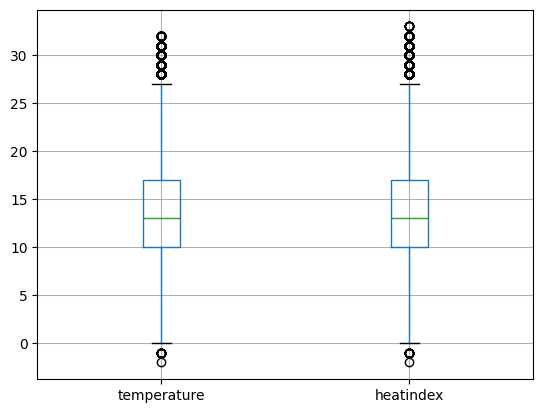

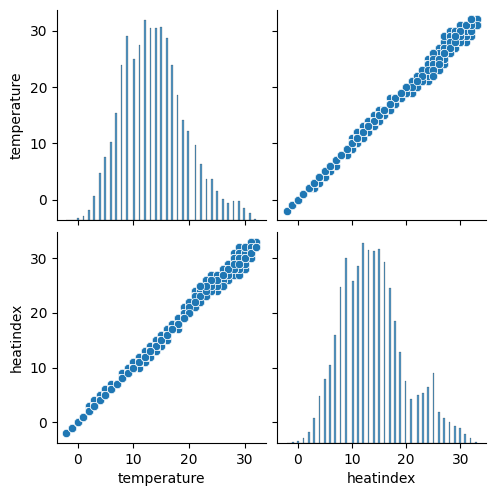

tempeature and heatindex are linear correlated.
So we can conclude those variables provide the same information and one of them can be deleted.


In [39]:
# more temperature and headindex 

# compare description and boxplot
print('\nDescription & Boxplot:')
temp_heat = weather_reduced[['temperature', 'heatindex']]

print(temp_heat.describe())

plt.figure()
temp_heat.boxplot()
sns.pairplot(data=temp_heat)
plt.show()

print('tempeature and heatindex are linear correlated.')
print('So we can conclude those variables provide the same information and one of them can be deleted.' )

__Variables: windchill vs. feelslike__

Windchill and Fellslike seem to be almost equal variables:

Description & Boxplot:
          windchill     feelslike
count  78624.000000  78624.000000
mean      12.926804     12.998766
std        6.374721      6.507605
min       -6.000000     -6.000000
25%        8.000000      8.000000
50%       12.000000     12.000000
75%       17.000000     17.000000
max       32.000000     33.000000

Comparison windchil vs feelslike [ROUNDED MEAN]
windchill
-6.0   -6
-5.0   -5
-4.0   -4
-3.0   -3
-2.0   -2
-1.0   -1
 0.0    0
 1.0    1
 2.0    2
 3.0    3
Name: feelslike, dtype: int64


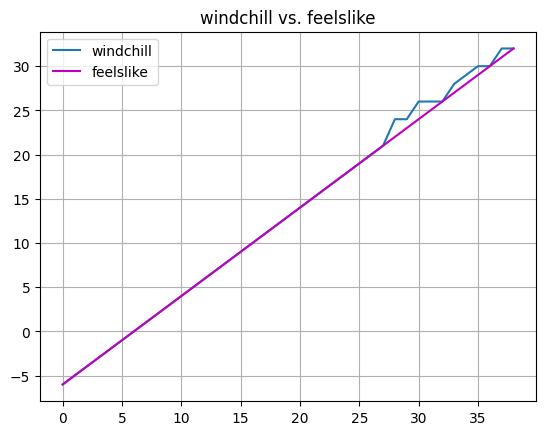


Analysis: We can see the same behaviour as in the former realtionships (linear correlation), so one (windchill or feelslike) can be deleted due to redundance.


In [40]:
# windchill and feelslike 
# seem to have redundant information, too

print('Windchill and Fellslike seem to be almost equal variables:\n')
print('Description & Boxplot:')
wind_feel = weather_reduced[['windchill', 'feelslike']]

print(wind_feel.describe())

wind_chill = weather_reduced.groupby('windchill')['feelslike'].apply(lambda x: set(x))
wind_chill_mean = weather_reduced.groupby('windchill')['feelslike'].apply(lambda x: round(np.mean(list(set(x)))))

print('\nComparison windchil vs feelslike [ROUNDED MEAN]')
print(wind_chill_mean[:10])

plt.figure()
#wind_feel.boxplot()
#sns.pairplot(data=wind_feel)

# linechart for visual comparison
xxx = range(len(wind_chill))
plt.plot(xxx, wind_chill_mean, label='windchill')
plt.plot(xxx, wind_chill_mean.index, c='m', label='feelslike')
plt.grid(True)
plt.title('windchill vs. feelslike')
plt.legend()

plt.show()

print('\nAnalysis: We can see the same behaviour as in the former realtionships (linear correlation), so one (windchill or feelslike) can be deleted due to redundance.')


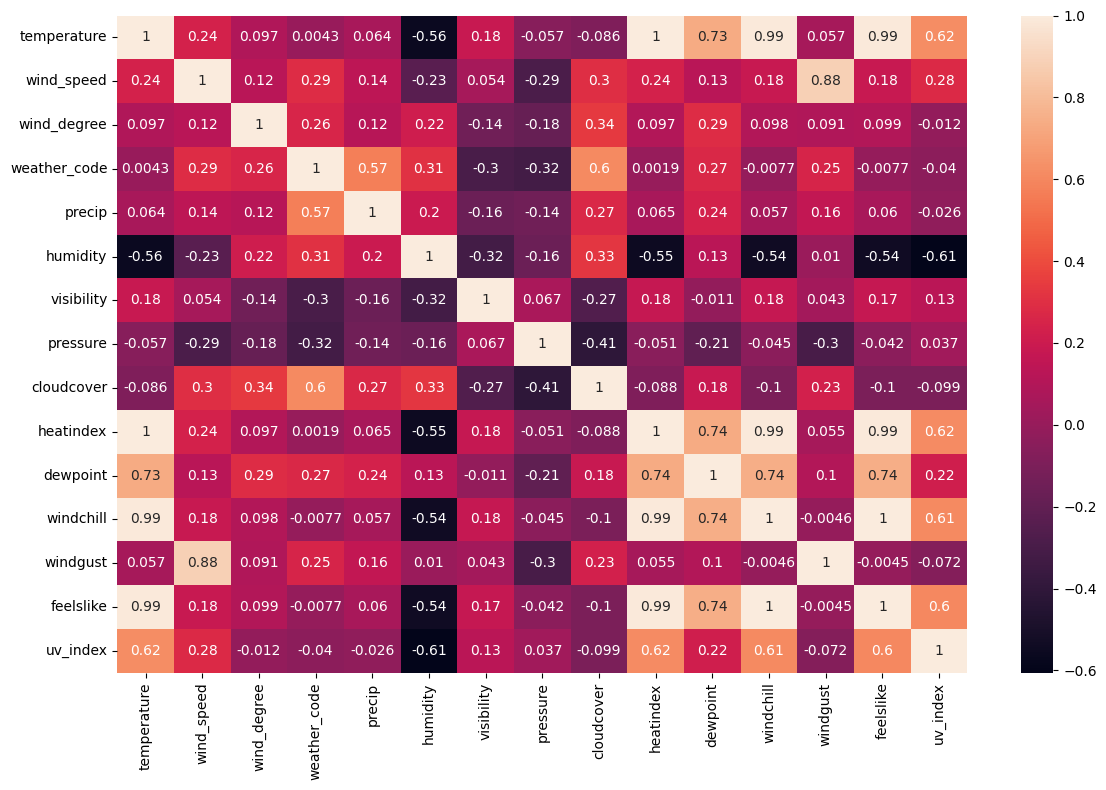

Temperature and Heatindex seem to be almost equal variables:
heatindex, temperature, windchill and feels like are almost 1 to 1 correlated


In [41]:
# all correlations in one heatmap visulized
plt.figure(figsize=(12,8))
sns.heatmap(weather_reduced.select_dtypes(['int', 'float']).corr(), annot=True)
plt.tight_layout()
plt.show()

print('Temperature and Heatindex seem to be almost equal variables:')
print('heatindex, temperature, windchill and feels like are almost 1 to 1 correlated')

In [42]:
# we just keep the temperature, because these 4 mentioned variable are perfectly correlated

delete_cols = ['windchill', 'heatindex', 'weather_code', 'feelslike']

# new df
weather_reduced_2 = weather_reduced.drop(columns=delete_cols)

weather_reduced_2.head()


,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index
0,2025-04-01,20:00,41812,10.0,16.0,79.0,ENE,Clear,0.0,56.0,10.0,1024.0,0.0,1.0,32.0,1.0
1,2025-04-01,21:00,41812,9.0,16.0,75.0,ENE,Clear,0.0,60.0,10.0,1024.0,1.0,1.0,32.0,1.0
2,2025-04-01,22:00,41812,9.0,18.0,71.0,ENE,Clear,0.0,62.0,10.0,1025.0,0.0,2.0,33.0,1.0
3,2025-04-01,23:00,41812,8.0,20.0,70.0,ENE,Clear,0.0,63.0,10.0,1025.0,2.0,2.0,35.0,1.0
4,2025-04-01,00:00,41812,6.0,10.0,52.0,NE,Clear,0.0,74.0,10.0,1028.0,0.0,2.0,21.0,1.0


### Prepare for visualisation and merging

In [43]:
# reducing weather df to day level, eleminating the hourly records

# what to groupby and what to aggragate (mean, etc..)
weather_per_day = weather_reduced_2.groupby(['date','zipcode']).agg({
 'temperature': 'mean',
 'wind_speed': 'mean',
 'wind_degree': 'mean',
 'wind_dir': lambda x: x.mode()[0],
 'weather_description': lambda y: y.mode()[0], 
 'precip': 'mean',
 'humidity': 'mean',
 'visibility': 'mean',
 'pressure': 'mean',
 'cloudcover': 'mean',
 'dewpoint': 'mean',
 'windgust': 'mean',
 'uv_index': 'mean'
 }
).reset_index()


# new weather df
display(weather_per_day.head())
print('Shape:', weather_per_day.shape)


,date,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index
0,2025-04-01,41812,8.750000,16.541667,72.333333,ENE,Clear,0.0,60.125000,10.0,1025.958333,6.125000,0.916667,25.750000,2.208333
1,2025-04-01,41836,8.750000,16.541667,72.333333,ENE,Clear,0.0,60.125000,10.0,1025.958333,6.125000,0.916667,25.750000,2.208333
2,2025-04-01,41849,8.416667,16.833333,72.083333,ENE,Clear,0.0,60.750000,10.0,1025.875000,5.666667,0.708333,26.708333,2.208333
3,2025-04-01,52062,7.541667,16.500000,78.625000,E,Clear,0.0,64.458333,10.0,1025.750000,5.833333,0.750000,25.958333,2.166667
4,2025-04-01,52064,7.541667,16.500000,78.625000,E,Clear,0.0,64.458333,10.0,1025.750000,5.833333,0.750000,25.958333,2.166667


Shape: (3276, 15)


## __Creating one final dataframe for modeling__

### Merging

In [44]:
# dataframes to merge

print('Sales:')
display(sales_adj.head(2))
print(sales_adj.shape)

print('\nStores:')
display(stores.tail(2))
print(stores.shape)

print('\nHoliday:')
display(holidays.head(2))
print(holidays.shape)

print('\nweather_per_day:')
display(weather_per_day.head())
print(weather.shape)

Sales:


,date,category_name,item_id,sold_quantity,price,revenue,store_id,month,day_of_week,week
0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0,4,1,14
1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0,4,1,14


(802969, 10)

Stores:


,zipcode,average_weekly_revenue_Q1,store_id
82,52393,0.0,82
83,52385,0.0,83


(84, 3)

Holiday:


,zipcode,date,holiday_name,holiday_type,is_holiday,day_of_month,week
0,41812,2025-04-01,Zuckerfest,special_day,1,1,14
1,41812,2025-04-02,Zuckerfest,special_day,1,2,14


(1301, 7)

weather_per_day:


,date,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index
0,2025-04-01,41812,8.750000,16.541667,72.333333,ENE,Clear,0.0,60.125000,10.0,1025.958333,6.125000,0.916667,25.750000,2.208333
1,2025-04-01,41836,8.750000,16.541667,72.333333,ENE,Clear,0.0,60.125000,10.0,1025.958333,6.125000,0.916667,25.750000,2.208333
2,2025-04-01,41849,8.416667,16.833333,72.083333,ENE,Clear,0.0,60.750000,10.0,1025.875000,5.666667,0.708333,26.708333,2.208333
3,2025-04-01,52062,7.541667,16.500000,78.625000,E,Clear,0.0,64.458333,10.0,1025.750000,5.833333,0.750000,25.958333,2.166667
4,2025-04-01,52064,7.541667,16.500000,78.625000,E,Clear,0.0,64.458333,10.0,1025.750000,5.833333,0.750000,25.958333,2.166667


(78624, 30)


### __Final Dataframe__

In [45]:
df = pd.merge(sales_adj, stores[['zipcode', 'store_id']],
              left_on='store_id', right_on='store_id', how='left')
df = pd.merge(df, weather_per_day, left_on=['date', 'zipcode'], right_on= ['date', 'zipcode'], how = 'left')
df['date_zipcode'] = df['zipcode'].astype('str') + df['date'].astype('str')
df['special_day'] = df['date_zipcode'].isin(special_days_index).astype('int')
df['school_holiday'] = df['date_zipcode'].isin(school_holidays_index).astype('int')
df['std_holiday'] = df['date_zipcode'].isin(std_holidays_index).astype('int')
df.head()

,date,category_name,item_id,sold_quantity,price,revenue,store_id,month,day_of_week,week,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday
0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
2,2025-04-01,Angebot Heißgetränke,346,25.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
3,2025-04-01,Angebot Heißgetränke,445,5.0,1.4,7.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
4,2025-04-01,Angebot Snack,330,5.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0


In [46]:
# shape
print('Shape:', df.shape, end='\n\n')

# info
print(df.info())

## next step: pre-processing for modeling

Shape: (802969, 28)

<class 'pandas.DataFrame'>
RangeIndex: 802969 entries, 0 to 802968
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 802969 non-null  datetime64[ns]
 1   category_name        802969 non-null  object        
 2   item_id              802969 non-null  int64         
 3   sold_quantity        802969 non-null  float64       
 4   price                802969 non-null  float64       
 5   revenue              802969 non-null  float64       
 6   store_id             802969 non-null  int64         
 7   month                802969 non-null  int32         
 8   day_of_week          802969 non-null  int32         
 9   week                 802969 non-null  UInt32        
 10  zipcode              802969 non-null  object        
 11  temperature          802969 non-null  float64       
 12  wind_speed           802969 non-null  float64       
 13  wind

# __Visualization__


### __Sales per store__

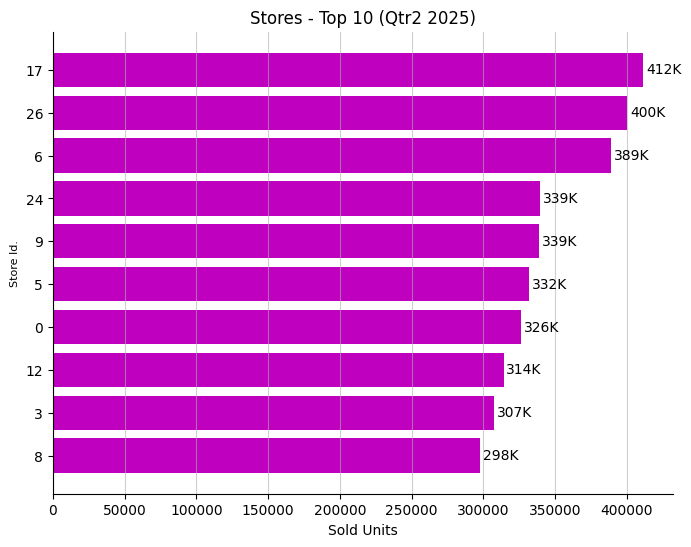

In [47]:
# Top 10 stores

#top_10_stores = sales.groupby('store_id').agg(sold_qty_sum=('sold_quantity', 'sum'), sold_qty_std=('sold_quantity', 'std')).sort_values('sold_qty_sum', ascending=False)
top_10_stores = df.groupby('store_id').agg(sold_qty_sum=('sold_quantity', 'sum'), sold_qty_std=('sold_quantity', 'std')).sort_values('sold_qty_sum', ascending=False)
top_10_stores = top_10_stores.head(10).sort_values('sold_qty_sum', ascending=True)
top_10_stores


# Top 10 stores: plot

fig, ax = plt.subplots(1,1, figsize=(8,6))

# top 10 category items
bars = ax.barh(top_10_stores.index.astype(str), top_10_stores.sold_qty_sum,  color='m')
bar_labels = [f'{v/1e3:.0f}K' if v < 1e6 else f'{v/1e6:.2f}M' for v in top_10_stores.sold_qty_sum]
ax.bar_label(bars, labels=bar_labels, padding=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.set_xlim(1.3e5, 3.6e5)

ax.set_xlabel('Sold Units')
ax.set_ylabel('Store Id.', fontsize=8)
ax.set_title('Stores - Top 10 (Qtr2 2025)')

ax.grid(axis='x', alpha=0.6, )

plt.show()

#### __Sales per week / weekday__

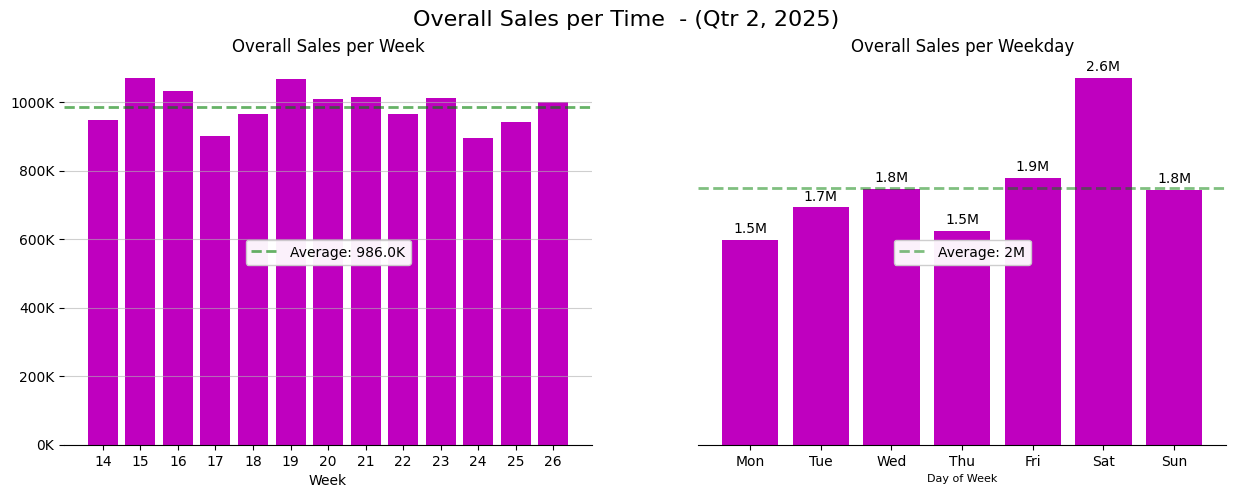

In [48]:
# sales per week and weekday

sales_per_week = df.groupby('week')['sold_quantity'].sum()[:-1] # last week incomplete
#sales_per_week = sales_adj.groupby('week')['sold_quantity'].sum()[:-1] # last week incomplete
#print('Sales per week:')
#print(sales_per_week)

qty_mean = sales_per_week.mean()
#print('Mean sold qty')
#print(qty_mean)

## -- plots

fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].bar(sales_per_week.index, sales_per_week, color='m')
ax[0].set_xticks(sales_per_week.index)
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[0].axhline(qty_mean, color='g', alpha=0.6, lw=2, ls='--', label=f'Average: {qty_mean/1e3:,.1f}K')

ax[0].set_xlabel('Week')
#ax[0].set_ylabel('QTY')

ax[0].set_title('Overall Sales per Week')


# ---------------------

sales_per_weekday = sales_adj.groupby('day_of_week')['sold_quantity'].sum()
#print('Sales per day_of_week:')
#print(sales_per_weekday)

qty_mean = sales_per_weekday.mean()
#print('Mean sold qty')
#print(qty_mean)

bars = ax[1].bar(sales_per_weekday.index, sales_per_weekday, color='m')

ax[1].set_xticks(sales_per_weekday.index, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6}M'))

ax[1].axhline(qty_mean, color='g', alpha=0.5, lw=2, ls='--', label=f'Average: {qty_mean/1e6:,.0f}M')

ax[1].set_xlabel('Day of Week', fontsize=8)
#ax[1].set_ylabel('QTY', fontsize=8)
ax[1].set_yticks([])

ax[1].set_title('Overall Sales per Weekday')

# adding bar labels on top
bar_labels = [f'{v/1e6:,.1f}M' for v in sales_per_weekday]
ax[1].bar_label(bars, labels=bar_labels , padding=3)


# ------ for all

for a in ax:
    a.grid(axis='y', alpha=.6)
    a.spines[['top', 'left', 'right']].set_visible(False)
    a.legend(loc='center', framealpha=0.95)

fig.suptitle('Overall Sales per Time  - (Qtr 2, 2025)', fontsize=16)
plt.show()

#### __Sales per category / item__

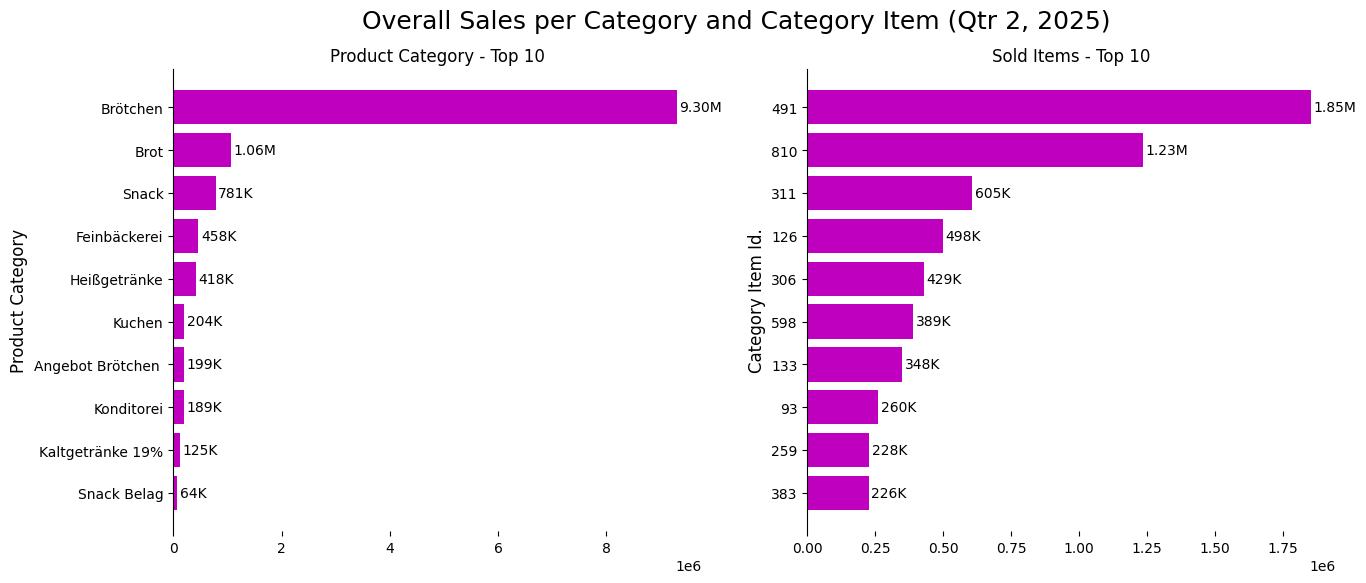

In [49]:
# Top 10 Category ---

#cat_sales = sales_adj.groupby('category_name')['sold_quantity'].sum().sort_values(ascending=False)
cat_sales = df.groupby('category_name')['sold_quantity'].sum().sort_values(ascending=False)

#print('Overall sold_quantity by category:')
#display(cat_sales)

top_10_cat = cat_sales.head(10)

top_10_cat = pd.DataFrame(top_10_cat).sort_values('sold_quantity', ascending=True)

#display(top_10_cat)

## ----------------------------------------------

# Top 10 Sold Items ---

item_sales = sales_adj.groupby('item_id')['sold_quantity'].sum().sort_values(ascending=False)

top_10_item = item_sales.sort_values(ascending=False).head(10)

top_10_item = pd.DataFrame(top_10_item).sort_values('sold_quantity')


# Top 10 Category: plot


fig, ax = plt.subplots(1,2, figsize=(15,6))


# top 10 category
bar_cat = ax[0].barh( top_10_cat.index.astype(str), top_10_cat.sold_quantity, color='m')

bar_labels = [f'{v/1e3:.0f}K' if v < 1e6 else f'{v/1e6:.2f}M' for v in top_10_cat.sold_quantity]

ax[0].bar_label(bar_cat, labels=bar_labels, padding=2)

ax[0].set_ylabel('Product Category', fontsize=12)
ax[0].set_title('Product Category - Top 10')


# ----------------

# Top 10 Sold Items: plot


# top 10 category items
bars_item = ax[1].barh(top_10_item.index.astype(str), top_10_item.sold_quantity,  color='m')

bar_labels = [f'{v/1e3:.0f}K' if v < 1e6 else f'{v/1e6:.2f}M' for v in top_10_item.sold_quantity]

ax[1].bar_label(bars_item, labels=bar_labels, padding=2)

ax[1].set_ylabel('Category Item Id.', fontsize=12)
ax[1].set_title('Sold Items - Top 10')

# for all plots-----

for a in ax:
    #a.grid(axis='x', alpha=0.6)
    a.spines[['top', 'bottom', 'right']].set_visible(False)
    #a.set_xticks([])

fig.suptitle('Overall Sales per Category and Category Item (Qtr 2, 2025)', fontsize=18)

plt.show()


#### __Distribution of sold_quantity__

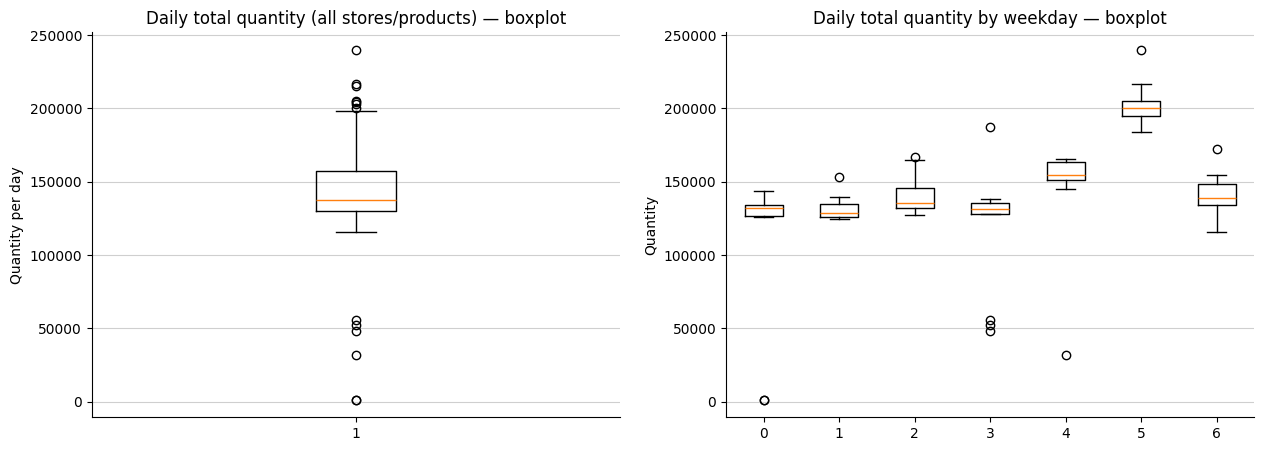

In [50]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

daily_total = sales_adj.groupby(["date", "day_of_week"], as_index=False)["sold_quantity"].sum()

ax[0].boxplot(daily_total["sold_quantity"].values, vert=True)
ax[0].set_title("Daily total quantity (all stores/products) — boxplot")
ax[0].set_ylabel("Quantity per day")


order = np.arange(7)
data_by_dow = [daily_total.loc[daily_total["day_of_week"] == d, "sold_quantity"].values for d in order]

ax[1].boxplot(data_by_dow, tick_labels=order, vert=True)
ax[1].set_title("Daily total quantity by weekday — boxplot")
ax[1].set_ylabel("Quantity")

for a in ax:
    a.grid(axis='y', alpha=0.6)
    a.spines[['top', 'right']].set_visible(False)

plt.show()



#### __Sales per category per weekday__

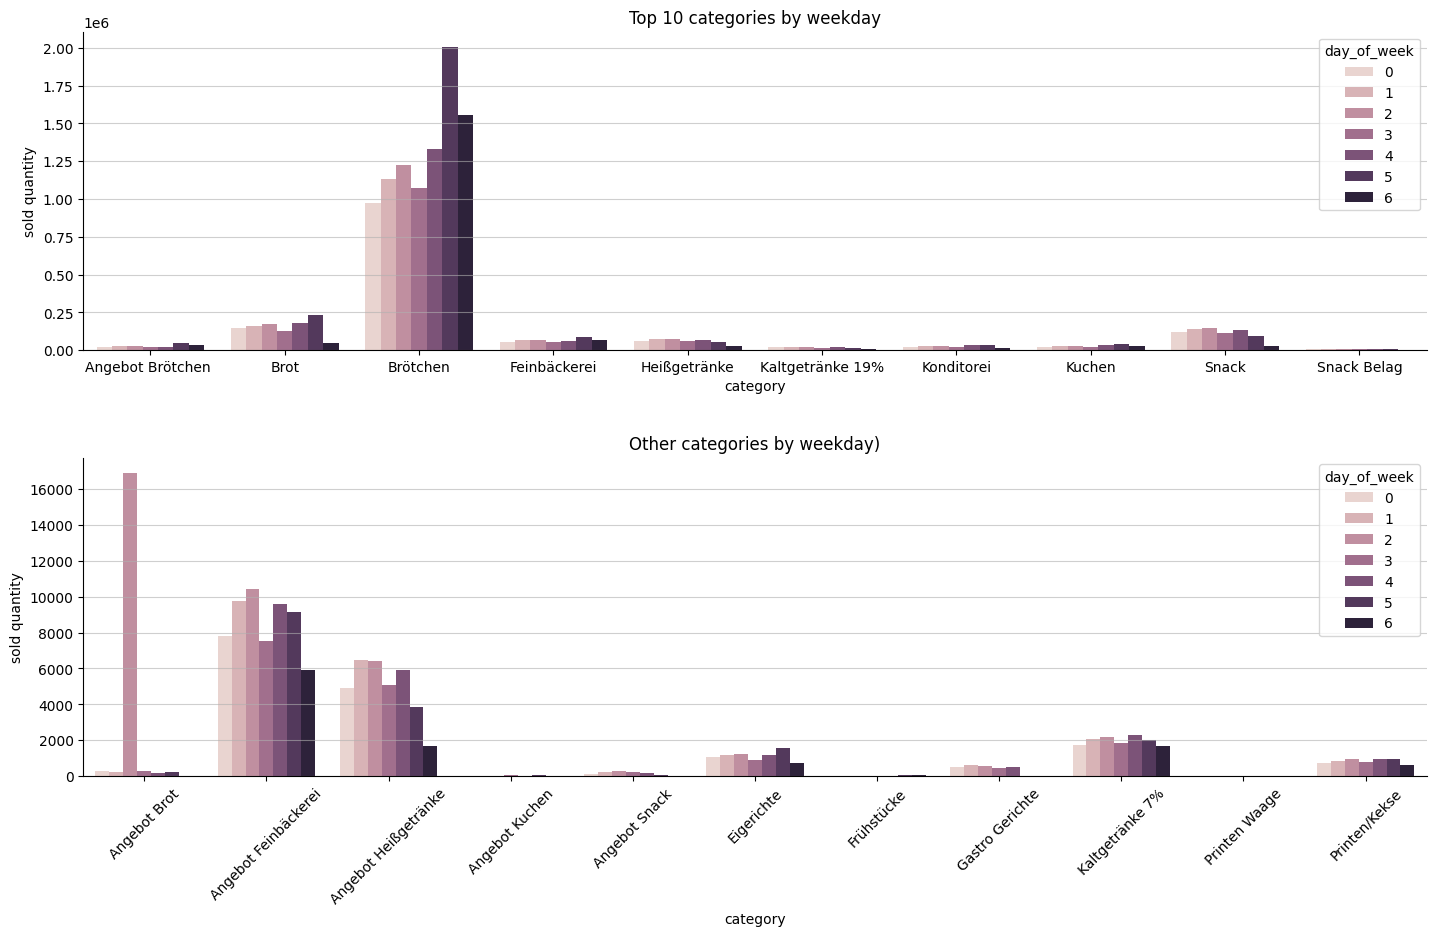

In [51]:
fig, ax = plt.subplots(2,1, figsize=(15,10))

# top 10 catagories per weekday
sales_agg2 = df[['category_name', 'day_of_week', 'sold_quantity']].groupby(['category_name', 'day_of_week' ]).sum()
sales_agg2 = sales_agg2.reset_index()
sales_agg2_top = sales_agg2[sales_agg2['category_name'].isin(top_10_cat.index)]

sns.barplot(x = 'category_name', y = 'sold_quantity', hue = 'day_of_week', data = sales_agg2_top, ax=ax[0])
ax[0].set_xlabel('category')
ax[0].set_ylabel('sold quantity')
ax[0].set_title('Top 10 categories by weekday')


# other categories per weekday
sales_agg2_other = sales_agg2[~ sales_agg2['category_name'].isin(top_10_cat.index)]

sns.barplot(x = 'category_name', y = 'sold_quantity', hue = 'day_of_week', data = sales_agg2_other, ax=ax[1])
ax[1].set_xlabel('category')
ax[1].set_ylabel('sold quantity')
ax[1].set_title('Other categories by weekday)')
ax[1].tick_params(axis='x', labelrotation=45)

for a in ax:
    a.grid(axis='y', alpha=0.6)
    a.spines[['top', 'right']].set_visible(False)
    
plt.tight_layout(pad=3)
plt.show()



#### __Distribution of sold quantities per category__

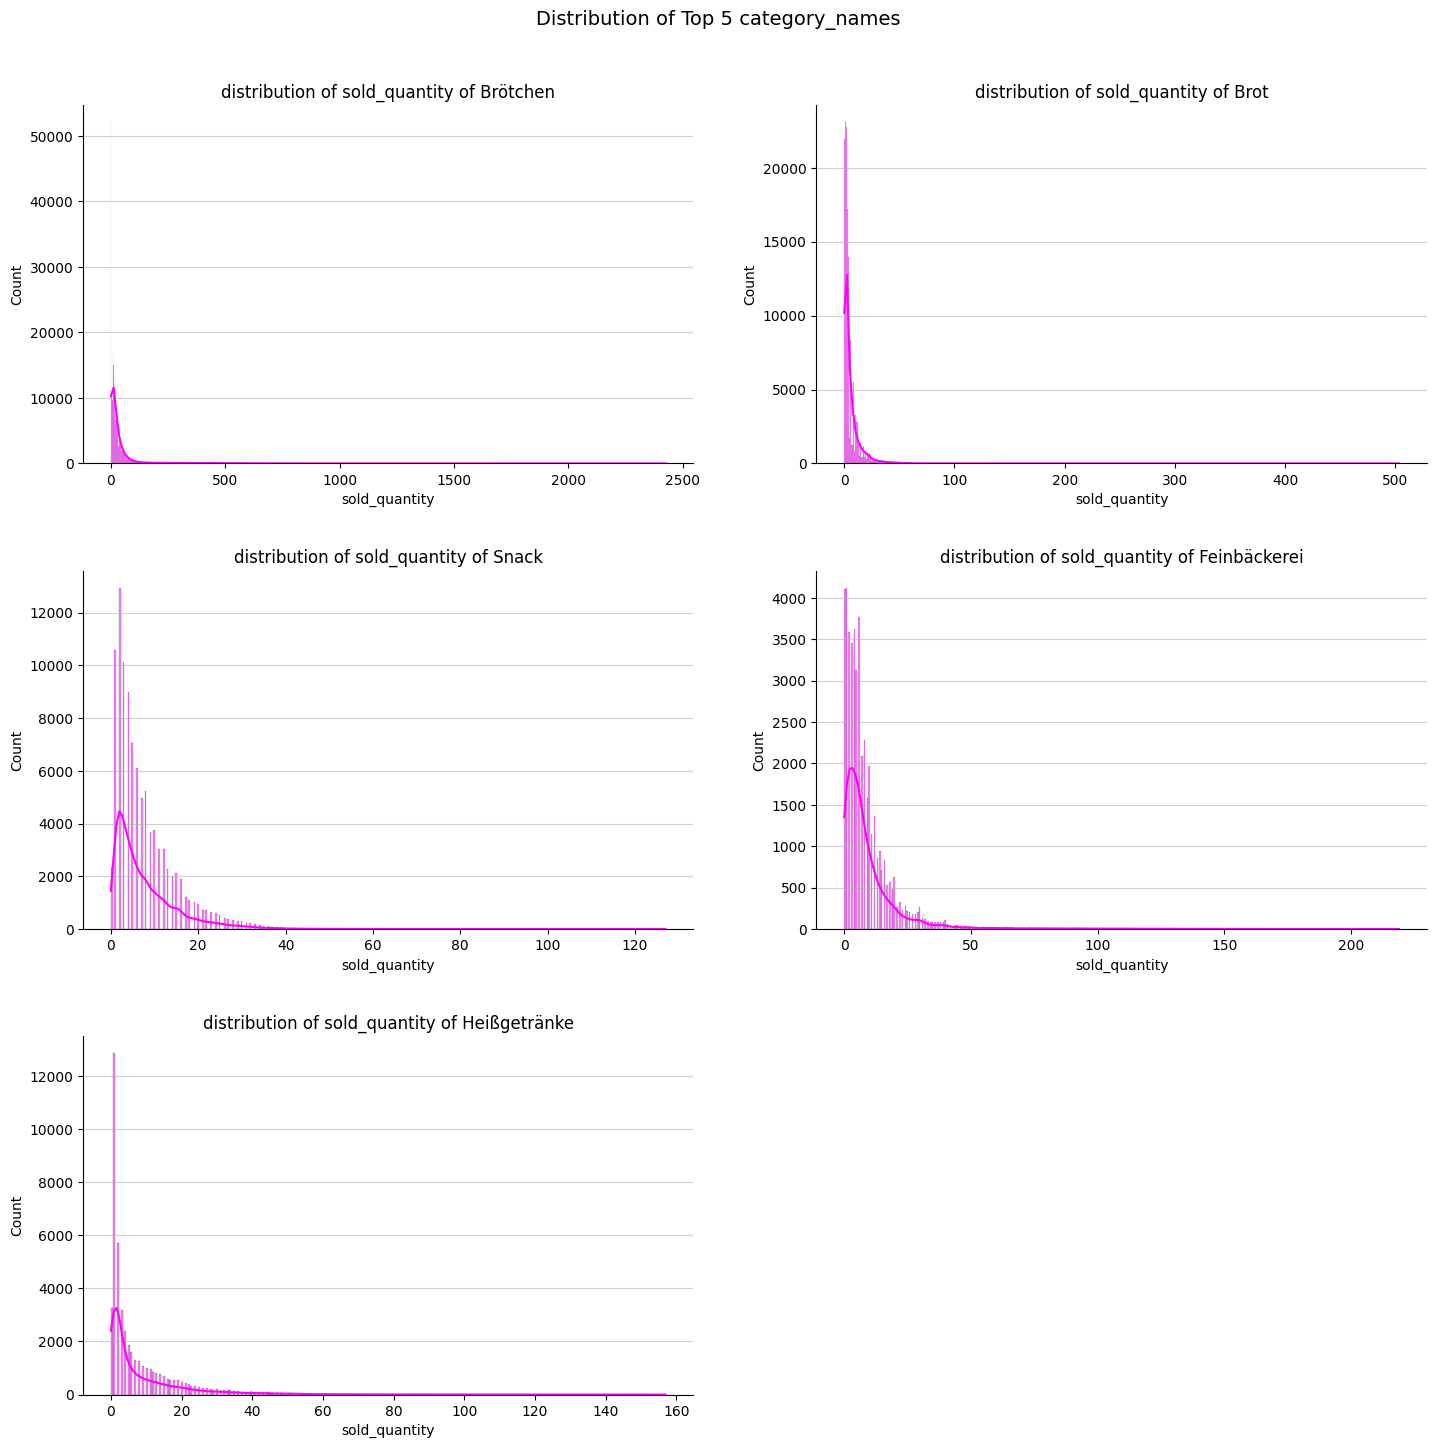

In [52]:
# distribution of top 5 categories 

#print(top_10_cat.sort_values('sold_quantity', ascending=False))

categories = top_10_cat.sort_values('sold_quantity', ascending=False).index[:5]
categories = categories.astype('str')

fig, ax = plt.subplots(3,2, figsize=(15,15))
ax = ax.flatten()

for i, category in enumerate(categories):
    #picture_name = category + '_quant_hist.png'
    
    sns.histplot(df[df['category_name'] == category]['sold_quantity'], kde=True, ax=ax[i], color='magenta')
    ax[i].set_title('distribution of sold_quantity of ' + category)
    ax[i].grid(axis='y', alpha=0.6)
    ax[i].spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution of Top 5 category_names', fontsize=14)
fig.delaxes(ax[5]) 
plt.tight_layout(pad=3)
plt.show() 


In [53]:
daily_total = df.groupby("date", as_index=False)["sold_quantity"].sum()
daily_total.head()

,date,sold_quantity
0,2025-04-01,135444.119
1,2025-04-02,145316.273
2,2025-04-03,138109.704
3,2025-04-04,156906.561
4,2025-04-05,215563.109


#### __Impact of holidays on sold quantities per category__

In [54]:
top_10_cat.index
top_10_wo_brotchen =['Snack Belag', 'Konditorei', 'Kaltgetränke 19%', 'Angebot Brötchen ',
       'Kuchen', 'Heißgetränke', 'Feinbäckerei', 'Snack', 'Brot']

__Special Day__

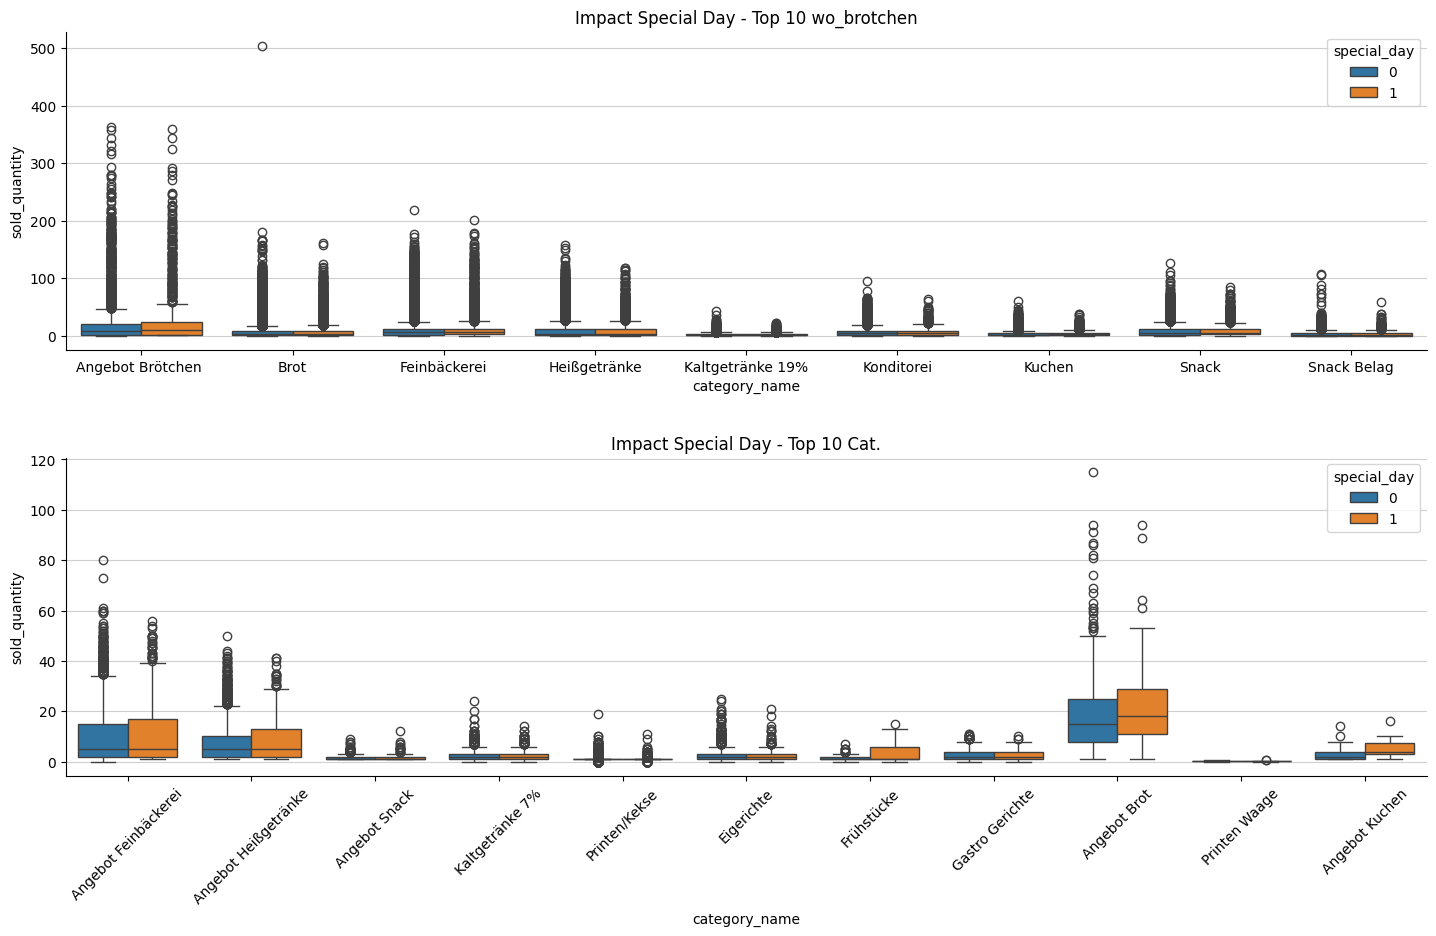

In [55]:
fig, ax = plt.subplots(2,1, figsize=(15,10))

sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(top_10_wo_brotchen)], hue='special_day', ax=ax[0])
ax[0].set_title('Impact Special Day - Top 10 wo_brotchen')

sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[~df['category_name'].isin(top_10_cat.index)], hue='special_day', ax=ax[1])
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_title('Impact Special Day - Top 10 Cat.')

for a in ax:
    a.grid(axis='y', alpha=0.6)
    a.spines[['top', 'right']].set_visible(False)

plt.tight_layout(pad=3)
plt.show()

__School Holiday__

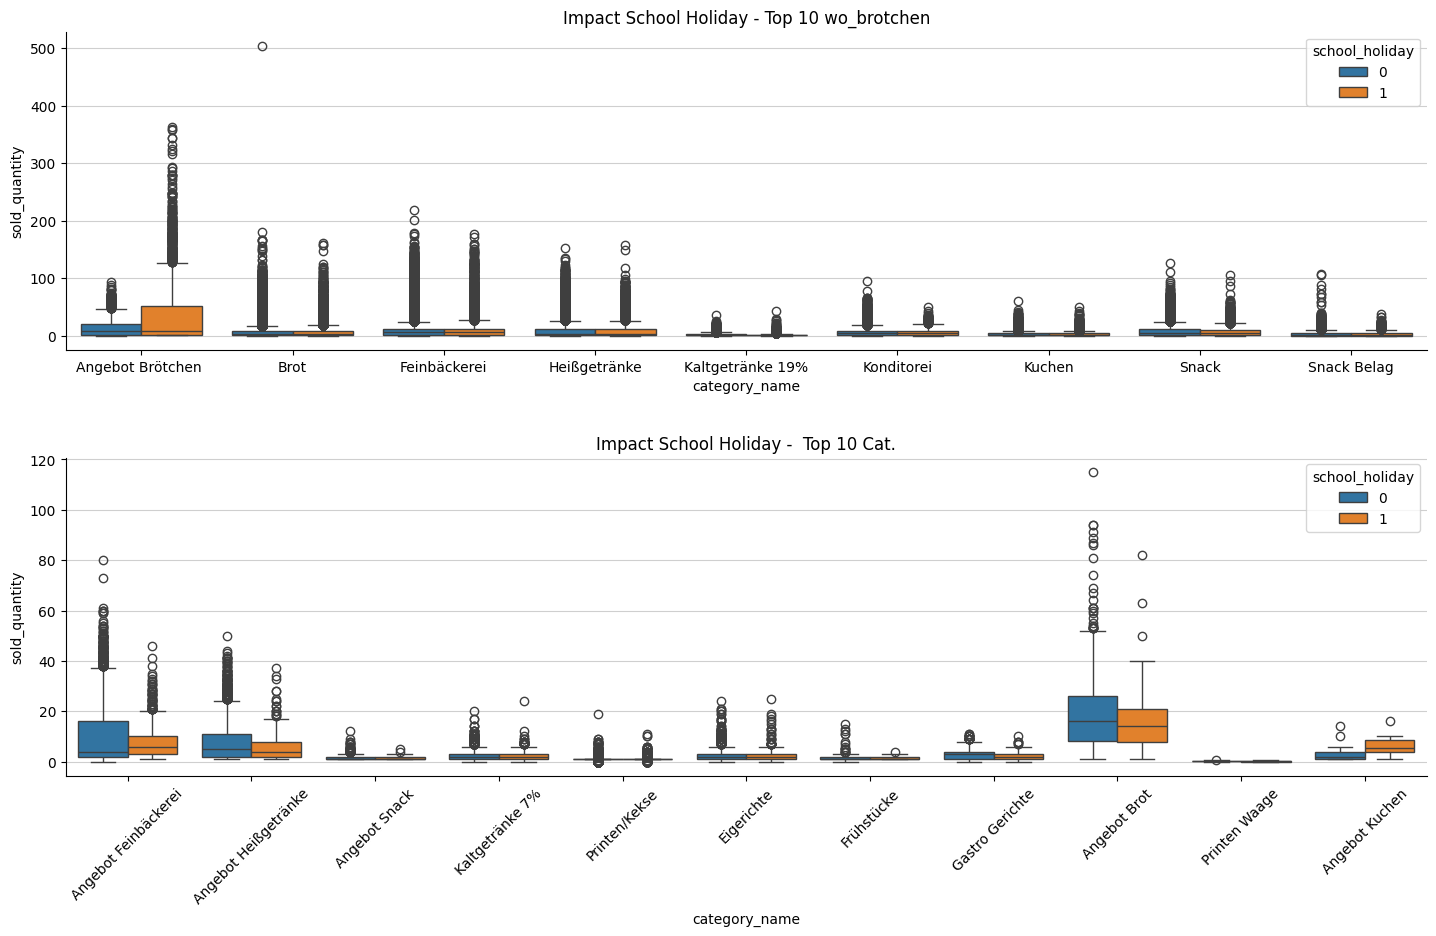

In [56]:
fig, ax = plt.subplots(2,1, figsize=(15,10))

sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(top_10_wo_brotchen)], hue='school_holiday', ax=ax[0])
ax[0].set_title('Impact School Holiday - Top 10 wo_brotchen')

sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[~df['category_name'].isin(top_10_cat.index)], hue='school_holiday', ax=ax[1])
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_title('Impact School Holiday -  Top 10 Cat.')

for a in ax:
    a.grid(axis='y', alpha=0.6)
    a.spines[['top', 'right']].set_visible(False)

plt.tight_layout(pad=3)
plt.show()



__Standard Holiday__

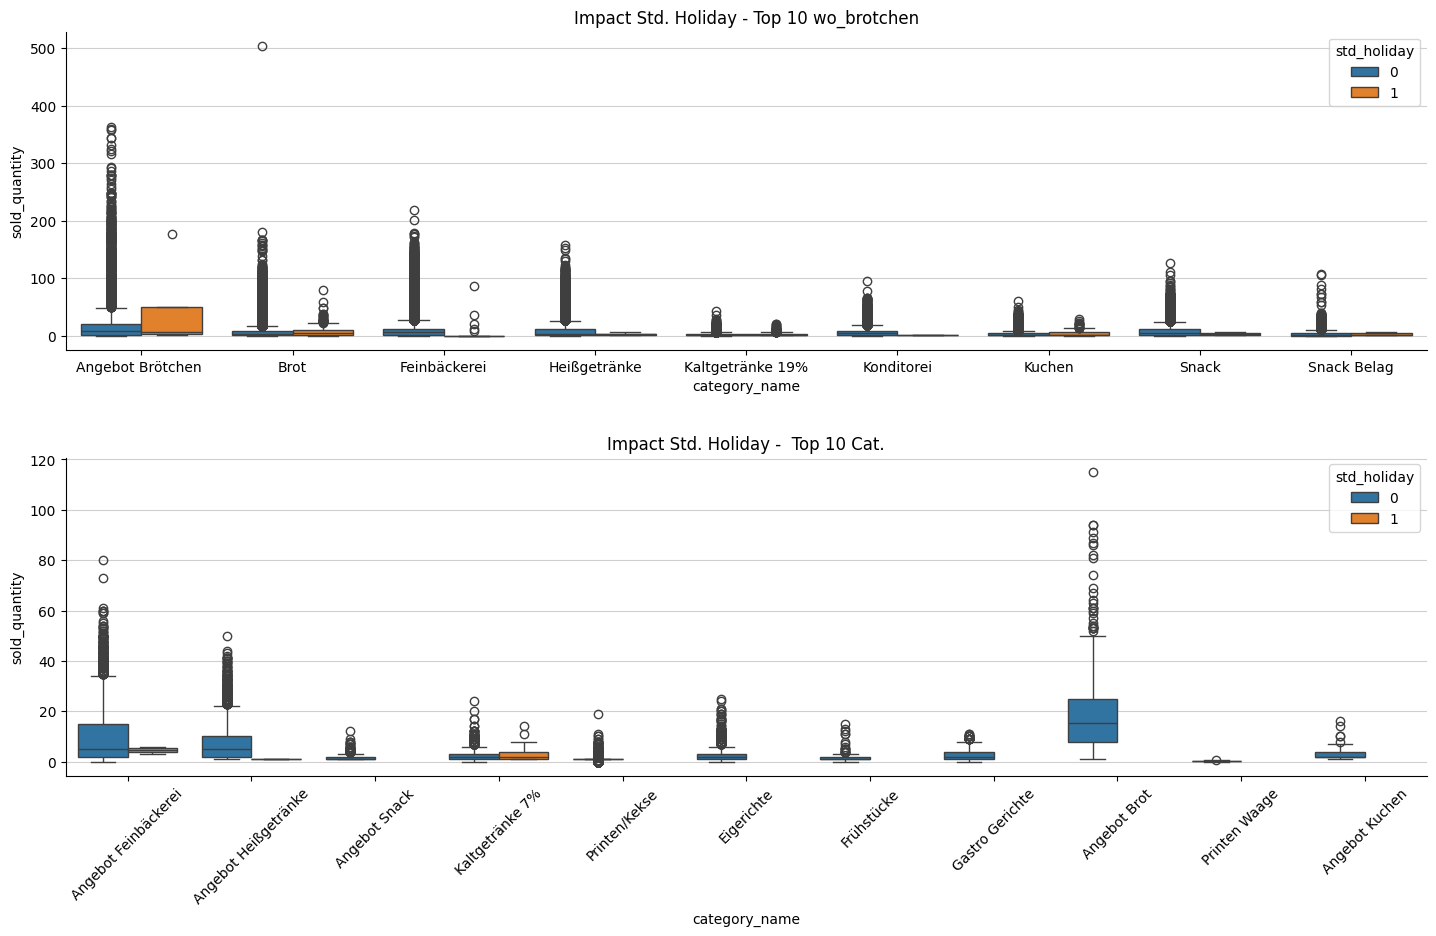

In [57]:
fig, ax = plt.subplots(2,1, figsize=(15,10))

sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(top_10_wo_brotchen)], hue='std_holiday', ax=ax[0])
ax[0].set_title('Impact Std. Holiday - Top 10 wo_brotchen')

sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[~df['category_name'].isin(top_10_cat.index)], hue='std_holiday', ax=ax[1])
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_title('Impact Std. Holiday -  Top 10 Cat.')

for a in ax:
    a.grid(axis='y', alpha=0.6)
    a.spines[['top', 'right']].set_visible(False)

plt.tight_layout(pad=3)
plt.show()


In [58]:
df.head()

,date,category_name,item_id,sold_quantity,price,revenue,store_id,month,day_of_week,week,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday
0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
2,2025-04-01,Angebot Heißgetränke,346,25.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
3,2025-04-01,Angebot Heißgetränke,445,5.0,1.4,7.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
4,2025-04-01,Angebot Snack,330,5.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0


In [59]:
# removing stores without revenue (store_id 60 to 83)
cond = df.store_id < 60
df = df[cond]


In [ ]:
# export to csv
df.to_csv('food_prediction_raw.csv', index=False)